In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [5]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [6]:
train = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\training_part1.h5")
train1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\training_part2.h5")
train2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\training_part3.h5")

In [19]:
train_df = pd.concat([train,train1,train2])

In [3]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [21]:
test = light_dark[(light_dark['animal'] =='J701NN') & (light_dark['date'] == '030624')]

In [58]:
test.time

196    4.733333
197    3.316667
198    4.583333
199    5.666667
200    6.000000
         ...   
328    5.200000
329    2.416667
330    4.033333
331    4.150000
332    2.266667
Name: time, Length: 137, dtype: float64

In [22]:
test.time.mean()

4.081143552311435

In [23]:
test.time.sum()

559.1166666666666

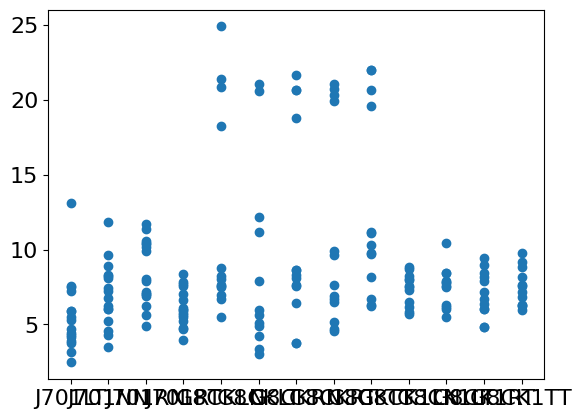

In [34]:
plt.scatter(light_trial_permin[light_trial_permin.task=='oa'].animal,light_trial_permin[light_trial_permin.task=='oa'].session_min)

<AxesSubplot: >

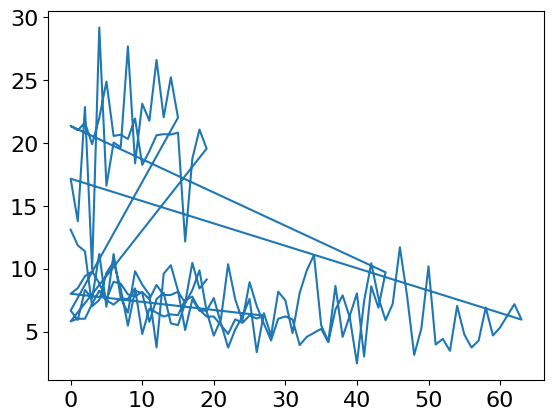

In [ ]:
light_dark

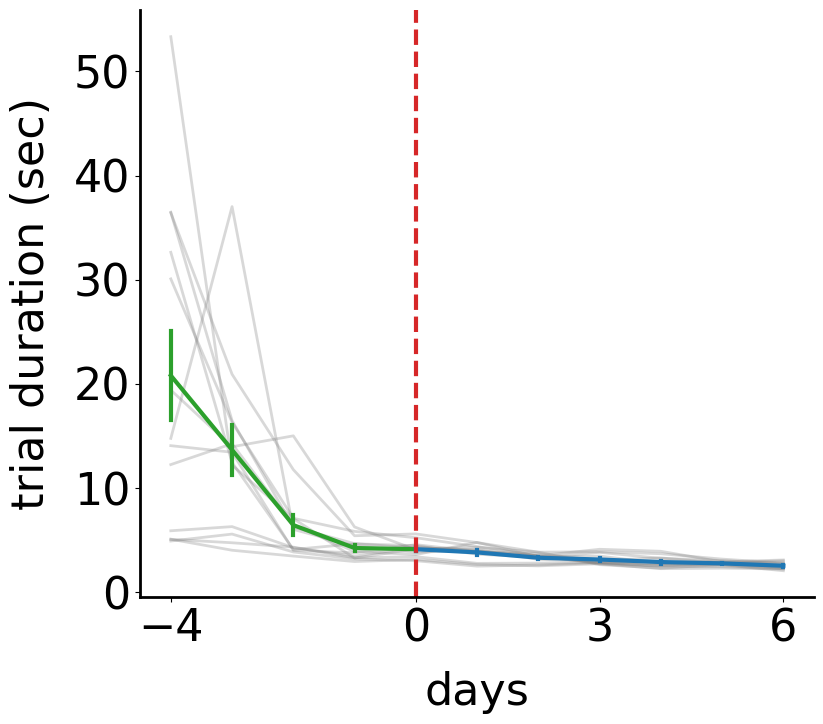

In [6]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trial duration (sec)', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trial_time for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trial_time'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trial_time'], 
             color='grey', alpha=0.3, linewidth=2)

# Split data into two segments for different colors
line_pre = line[line['date_index'] <= 0]
line_post = line[line['date_index'] >= 0]

# Plot pre-day 0 segment in green (error bars remain default/black)
if not line_pre.empty:
    sns.lineplot(ax=ax1, data=line_pre, x='date_index', y='trial_time', 
                 errorbar='se', err_style='bars', color='tab:green', 
                 linewidth=3, err_kws={'linewidth': 3})

# Plot post-day 0 segment in blue (error bars remain default/black)  
if not line_post.empty:
    sns.lineplot(ax=ax1, data=line_post, x='date_index', y='trial_time', 
                 errorbar='se', err_style='bars', color='tab:blue', 
                 linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()
plt.show()

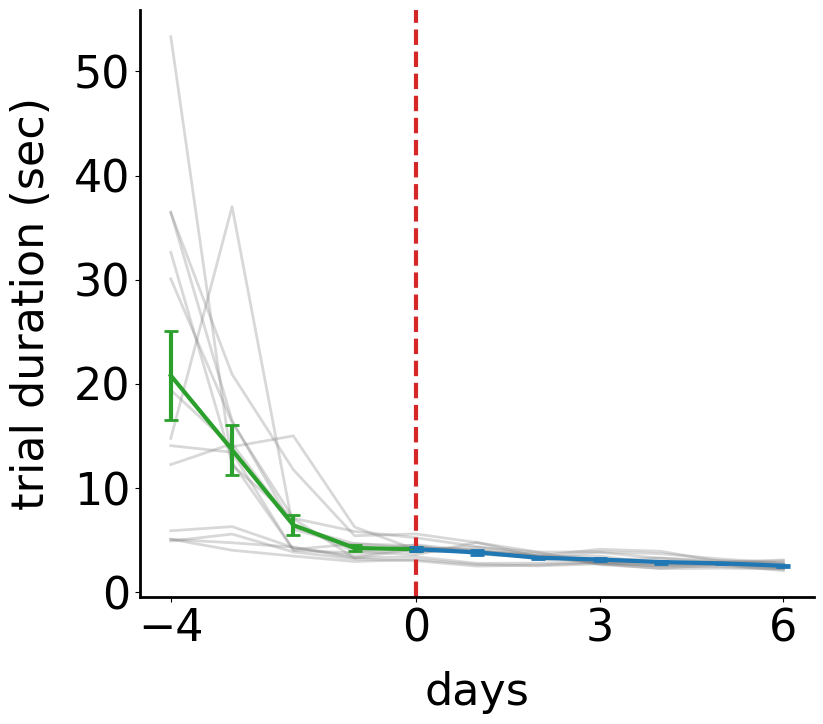

Population Statistics (mean of animal means):
Day | Mean ± SEM | n animals
----------------------------------------
-4.000000 | 20.811 ± 4.308 | 13.0
-3.000000 | 13.681 ± 2.412 | 13.0
-2.000000 | 6.462 ± 0.943 | 13.0
-1.000000 | 4.263 ± 0.299 | 13.0
0.000000 | 4.151 ± 0.208 | 13.0
1.000000 | 3.842 ± 0.207 | 13.0
2.000000 | 3.329 ± 0.119 | 13.0
3.000000 | 3.162 ± 0.140 | 13.0
4.000000 | 2.918 ± 0.142 | 13.0
5.000000 | 2.789 ± 0.065 | 13.0
6.000000 | 2.564 ± 0.089 | 13.0


In [33]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trial duration (sec)', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Store all animal means for each day
all_animal_means = []

# Plot individual animal lines with low alpha in grey and collect means
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trial_time for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trial_time'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trial_time'], 
             color='grey', alpha=0.3, linewidth=2)
    
    # Store animal means for calculating population mean
    all_animal_means.append(animal_means)

# Create a DataFrame for population statistics
population_stats = []

# Calculate population mean as mean of animal means for each day
all_days = sorted(line['date_index'].unique())
for day in all_days:
    day_means = []
    for animal_df in all_animal_means:
        day_data = animal_df[animal_df['date_index'] == day]
        if not day_data.empty:
            day_means.append(day_data['trial_time'].values[0])
    
    if day_means:  # Only process days where we have data
        population_mean = np.mean(day_means)
        population_sem = np.std(day_means, ddof=1) / np.sqrt(len(day_means)) if len(day_means) > 1 else 0
        population_stats.append({
            'date_index': day,
            'mean': population_mean,
            'sem': population_sem,
            'n_animals': len(day_means)
        })

# Convert to DataFrame
population_df = pd.DataFrame(population_stats)

# Split population data into two segments for different colors
population_pre = population_df[population_df['date_index'] <= 0]
population_post = population_df[population_df['date_index'] >= 0]

# Plot pre-day 0 segment in green using population means
if not population_pre.empty:
    # Plot the mean line
    ax1.plot(population_pre['date_index'], population_pre['mean'], 
             color='tab:green', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_pre['date_index'], population_pre['mean'],
                 yerr=population_pre['sem'], color='tab:green',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Plot post-day 0 segment in blue using population means  
if not population_post.empty:
    # Plot the mean line
    ax1.plot(population_post['date_index'], population_post['mean'], 
             color='tab:blue', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_post['date_index'], population_post['mean'],
                 yerr=population_post['sem'], color='tab:blue',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()
plt.show()

# Print population statistics in same format as previous plots
print("Population Statistics (mean of animal means):")
print("Day | Mean ± SEM | n animals")
print("-" * 40)
for _, row in population_df.iterrows():
    print(f"{row['date_index']:3f} | {row['mean']:.3f} ± {row['sem']:.3f} | {row['n_animals']}")

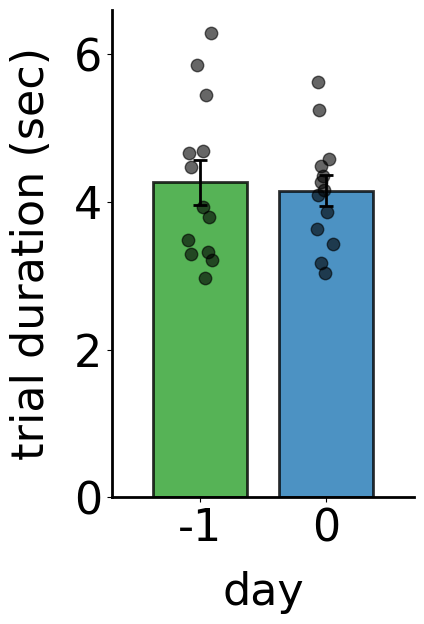

Summary Statistics:
Day -1: Mean = 4.26 ± 0.30 SEM, SD = 1.08, n = 13
Day 0: Mean = 4.15 ± 0.21 SEM, SD = 0.75, n = 13


In [18]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure
fig, ax = plt.subplots(1, 1, figsize=(5, 7))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('trial duration (sec)', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5 (closer than before)
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Smaller jitter since bars are closer

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean for this animal on this day
            animal_mean = animal_day_data['trial_time'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trial_time'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = .75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_time_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

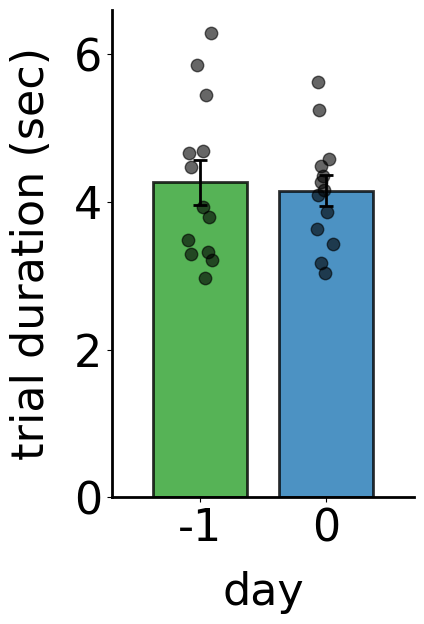

Summary Statistics:
Day -1: Mean = 4.26 ± 0.30 SEM, SD = 1.08, n = 13
Day 0: Mean = 4.15 ± 0.21 SEM, SD = 0.75, n = 13

PAIRED T-TEST RESULTS
Total animals: 13
Animals with complete data on both days: 13

Paired t-test (two-tailed):
t(12) = 0.497, p = 0.6282
Mean difference (Day 0 - Day -1): -0.112 ± 0.224 SEM
95% CI for mean difference: [-0.551, 0.328]
Significance: ns

Individual animal data (trial duration in seconds):
  Animal G8CK1LN: Day -1 = 2.97, Day 0 = 3.17, Difference = 0.20
  Animal G8CK1LT: Day -1 = 3.48, Day 0 = 4.35, Difference = 0.87
  Animal G8CK1RT: Day -1 = 3.22, Day 0 = 3.04, Difference = -0.18
  Animal G8CK1TT: Day -1 = 3.32, Day 0 = 3.43, Difference = 0.12
  Animal G8CKLN: Day -1 = 4.47, Day 0 = 3.87, Difference = -0.60
  Animal G8CKLT: Day -1 = 3.30, Day 0 = 4.17, Difference = 0.87
  Animal G8CKRN: Day -1 = 4.67, Day 0 = 4.49, Difference = -0.18
  Animal G8CKRT: Day -1 = 3.80, Day 0 = 4.58, Difference = 0.78
  Animal G8CKTT: Day -1 = 3.93, Day 0 = 3.63, Differenc

In [34]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure
fig, ax = plt.subplots(1, 1, figsize=(5, 7))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('trial duration (sec)', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5 (closer than before)
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Smaller jitter since bars are closer

# Prepare data for paired t-test
day_minus1_data = []
day_0_data = []
paired_data = []  # Store pairs for t-test

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean for this animal on this day
            animal_mean = animal_day_data['trial_time'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)
            
            # Collect data for t-test
            if day == -1:
                day_minus1_data.append(animal_mean)
            else:
                day_0_data.append(animal_mean)
            
            # Store for pairing
            paired_data.append({'animal': animal, 'day': day, 'mean_trial_time': animal_mean})

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trial_time'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = .75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_time_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

# Perform paired t-test
print("\n" + "="*50)
print("PAIRED T-TEST RESULTS")
print("="*50)

# Convert to DataFrame for easier pairing
import pandas as pd
paired_df = pd.DataFrame(paired_data)

# Create a pivot table to align data by animal
pivot_df = paired_df.pivot(index='animal', columns='day', values='mean_trial_time')
pivot_df = pivot_df.reset_index()

# Check if we have complete pairs (animals with data on both days)
complete_pairs = pivot_df.dropna()

print(f"Total animals: {len(unique_animals)}")
print(f"Animals with complete data on both days: {len(complete_pairs)}")

if len(complete_pairs) >= 2:
    # Perform paired t-test
    from scipy import stats
    
    # Extract paired data
    day_minus1_paired = complete_pairs[-1].values
    day_0_paired = complete_pairs[0].values
    
    # Perform the paired t-test
    t_stat, p_value = stats.ttest_rel(day_minus1_paired, day_0_paired)
    
    # Calculate descriptive statistics for the differences
    differences = day_0_paired - day_minus1_paired
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)  # Sample standard deviation
    sem_diff = std_diff / np.sqrt(len(differences))
    
    print(f"\nPaired t-test (two-tailed):")
    print(f"t({len(differences)-1}) = {t_stat:.3f}, p = {p_value:.4f}")
    print(f"Mean difference (Day 0 - Day -1): {mean_diff:.3f} ± {sem_diff:.3f} SEM")
    print(f"95% CI for mean difference: [{mean_diff - 1.96*sem_diff:.3f}, {mean_diff + 1.96*sem_diff:.3f}]")
    
    # Check for significance
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "ns"
    
    print(f"Significance: {significance}")
    
    # Print individual animal data
    print(f"\nIndividual animal data (trial duration in seconds):")
    for idx, row in complete_pairs.iterrows():
        print(f"  Animal {row['animal']}: Day -1 = {row[-1]:.2f}, Day 0 = {row[0]:.2f}, Difference = {row[0] - row[-1]:.2f}")
        
else:
    print("\nCannot perform paired t-test: Need at least 2 animals with data on both days")
    print(f"Animals with complete data: {list(complete_pairs['animal'])}")

print("\nNote: Paired t-test compares each animal's performance on Day -1 vs Day 0.")
print("This accounts for within-animal variability across days.")

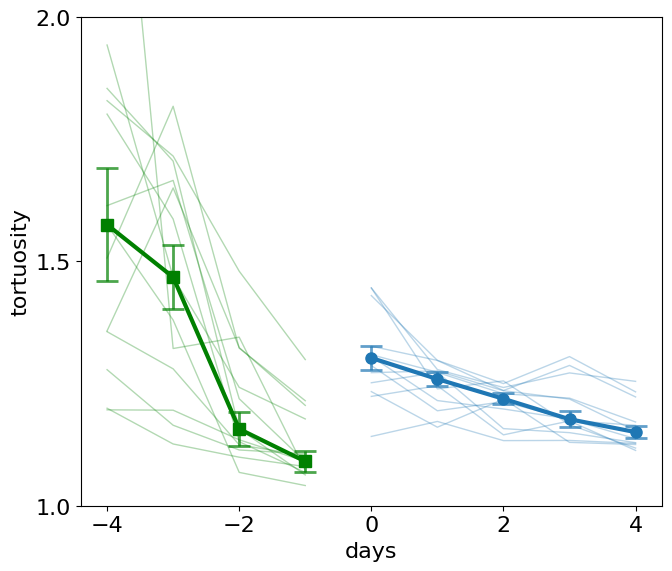

In [20]:
# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
#light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter train data to only include date_index from -4 to 2
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4 (adding date_index 4)
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Recalculate SEM based on individual animal medians for both datasets
train_sem_by_animal = train_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']

light_sem_by_animal = light_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']

# Merge the recalculated SEM back to population stats
train_population_stats = train_population_stats.merge(train_sem_by_animal, on='date_index')
light_population_stats = light_population_stats.merge(light_sem_by_animal, on='date_index')

# Plot train data (using original date_index)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='tab:blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem_animal'], 
             color='tab:blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces with lines
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animal traces
for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1,
             label='_nolegend_', zorder=1)

# Plot light/dark individual animal traces
for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='tab:blue', alpha=0.3, linewidth=1, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks([-4,-2,0,2,4])
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)



plt.tight_layout()

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\median_tortuosity_train_task_lines.pdf", 
#            dpi=300, transparent=True)
plt.show()

NameError: name 'train_df' is not defined

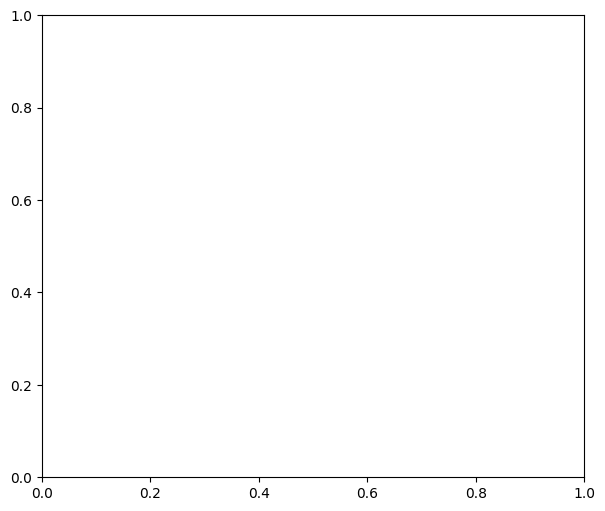

In [18]:
# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
#light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter train data to only include date_index from -4 to 2
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4 (adding date_index 4)
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Recalculate SEM based on individual animal medians for both datasets
train_sem_by_animal = train_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']

light_sem_by_animal = light_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']

# Merge the recalculated SEM back to population stats
train_population_stats = train_population_stats.merge(train_sem_by_animal, on='date_index')
light_population_stats = light_population_stats.merge(light_sem_by_animal, on='date_index')

# Calculate overall animal means across all days for statistical comparison
train_animal_means = train_animal_medians.groupby('animal')['tortuosity'].mean().reset_index()
train_animal_means.columns = ['animal', 'mean_tortuosity_train']
train_animal_means['condition'] = 'train'

light_animal_means = light_animal_medians.groupby('animal')['tortuosity'].mean().reset_index()
light_animal_means.columns = ['animal', 'mean_tortuosity_light']
light_animal_means['condition'] = 'light'

# Find animals that appear in both datasets for potential paired comparison
common_animals = set(train_animal_means['animal']).intersection(set(light_animal_means['animal']))

# Plot train data (using original date_index)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='tab:blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem_animal'], 
             color='tab:blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces with lines
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animal traces
for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1,
             label='_nolegend_', zorder=1)

# Plot light/dark individual animal traces
for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='tab:blue', alpha=0.3, linewidth=1, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks([-4,-2,0,2,4])
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)

plt.tight_layout()
plt.show()

# Print statistics for comparison
print("="*60)
print("STATISTICAL COMPARISON: TRAINING vs LIGHT/DARK CONDITION")
print("="*60)

print("\nOverall Animal Statistics:")
print(f"Training animals: {len(train_animal_means)}")
print(f"Light/Dark animals: {len(light_animal_means)}")
print(f"Animals in both conditions: {len(common_animals)}")

if len(common_animals) > 0:
    print(f"\nCommon animals: {sorted(common_animals)}")
    
    # Create combined dataframe for common animals
    combined_data = []
    for animal in common_animals:
        train_mean = train_animal_means[train_animal_means['animal'] == animal]['mean_tortuosity_train'].values[0]
        light_mean = light_animal_means[light_animal_means['animal'] == animal]['mean_tortuosity_light'].values[0]
        combined_data.append({
            'animal': animal,
            'train_mean': train_mean,
            'light_mean': light_mean,
            'difference': light_mean - train_mean
        })
    
    combined_df = pd.DataFrame(combined_data)
    
    print(f"\nIndividual animal means (common animals only):")
    print(f"{'Animal':<10} {'Train Mean':<12} {'Light Mean':<12} {'Difference':<12}")
    print("-"*50)
    for _, row in combined_df.iterrows():
        print(f"{row['animal']:<10} {row['train_mean']:<12.3f} {row['light_mean']:<12.3f} {row['difference']:<12.3f}")

# Calculate overall statistics for each condition
train_overall_mean = train_animal_means['mean_tortuosity_train'].mean()
train_overall_sem = train_animal_means['mean_tortuosity_train'].sem()
train_overall_std = train_animal_means['mean_tortuosity_train'].std()

light_overall_mean = light_animal_means['mean_tortuosity_light'].mean()
light_overall_sem = light_animal_means['mean_tortuosity_light'].sem()
light_overall_std = light_animal_means['mean_tortuosity_light'].std()

print(f"\nOverall Condition Means (averaged across days and animals):")
print(f"Training:  {train_overall_mean:.3f} ± {train_overall_sem:.3f} SEM (n={len(train_animal_means)})")
print(f"Light/Dark: {light_overall_mean:.3f} ± {light_overall_sem:.3f} SEM (n={len(light_animal_means)})")

# Perform statistical tests
from scipy import stats

print(f"\n" + "="*60)
print("STATISTICAL TESTS")
print("="*60)

# Helper function for significance stars
def get_significance(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# 1. Independent t-test (assuming different animals in each condition)
print(f"\n1. INDEPENDENT T-TEST (assuming different animals):")
t_stat_ind, p_value_ind = stats.ttest_ind(
    train_animal_means['mean_tortuosity_train'], 
    light_animal_means['mean_tortuosity_light'],
    equal_var=False  # Welch's t-test
)

mean_diff_ind = light_overall_mean - train_overall_mean
pooled_sem = np.sqrt((train_overall_sem**2 + light_overall_sem**2) / 2)

print(f"Welch's t-test: t = {t_stat_ind:.3f}, p = {p_value_ind:.4f}")
print(f"Mean difference (Light - Train): {mean_diff_ind:.3f}")
print(f"Significance: {get_significance(p_value_ind)}")

# 2. Paired t-test (only if we have common animals)
if len(common_animals) >= 2:
    print(f"\n2. PAIRED TESTS (common animals only, n={len(common_animals)}):")
    
    # Extract data for common animals
    train_common = combined_df['train_mean'].values
    light_common = combined_df['light_mean'].values
    
    # 2a. Paired t-test
    t_stat_paired, p_value_paired = stats.ttest_rel(light_common, train_common)
    
    differences = light_common - train_common
    mean_diff_paired = np.mean(differences)
    sem_diff_paired = np.std(differences, ddof=1) / np.sqrt(len(differences))
    
    print(f"\n   a) Paired t-test:")
    print(f"      t({len(differences)-1}) = {t_stat_paired:.3f}, p = {p_value_paired:.4f}")
    print(f"      Mean difference (Light - Train): {mean_diff_paired:.3f} ± {sem_diff_paired:.3f} SEM")
    print(f"      95% CI: [{mean_diff_paired - 1.96*sem_diff_paired:.3f}, {mean_diff_paired + 1.96*sem_diff_paired:.3f}]")
    print(f"      Significance: {get_significance(p_value_paired)}")
    
    # 2b. Wilcoxon signed-rank test (non-parametric paired test)
    print(f"\n   b) Wilcoxon signed-rank test (non-parametric):")
    
    # Check if differences have ties (all zeros or many identical differences)
    unique_differences = np.unique(differences)
    has_ties = len(unique_differences) < len(differences)
    
    try:
        # Try using the exact method first
        w_stat, p_value_wilcoxon = stats.wilcoxon(light_common, train_common, 
                                                  zero_method='wilcox', 
                                                  correction=True, 
                                                  mode='auto')
        
        # Calculate the effect size (matched pairs rank-biserial correlation)
        n_pairs = len(differences)
        n_pos = np.sum(differences > 0)
        n_neg = np.sum(differences < 0)
        n_zero = np.sum(differences == 0)
        effect_size = (n_pos - n_neg) / n_pairs
        
        print(f"      W = {w_stat:.1f}, p = {p_value_wilcoxon:.4f}")
        print(f"      N pairs = {n_pairs}")
        print(f"      Positive differences (Light > Train): {n_pos}")
        print(f"      Negative differences (Light < Train): {n_neg}")
        print(f"      Zero differences: {n_zero}")
        print(f"      Effect size (rank-biserial correlation): {effect_size:.3f}")
        
        # For interpretation
        if effect_size > 0:
            direction = "Light > Train"
        elif effect_size < 0:
            direction = "Light < Train"
        else:
            direction = "No difference"
            
        print(f"      Direction: {direction}")
        print(f"      Significance: {get_significance(p_value_wilcoxon)}")
        
        if has_ties:
            print(f"      Note: Data contains ties, using normal approximation")
        
    except Exception as e:
        print(f"      Error in Wilcoxon test: {e}")
        print(f"      Trying alternative method...")
        
        # Alternative calculation
        w_stat_alt, p_value_wilcoxon_alt = stats.wilcoxon(light_common, train_common, 
                                                          zero_method='pratt',
                                                          correction=True,
                                                          mode='approx')
        print(f"      W = {w_stat_alt:.1f}, p = {p_value_wilcoxon_alt:.4f} (approx)")
        print(f"      Significance: {get_significance(p_value_wilcoxon_alt)}")
        
else:
    print(f"\n2. PAIRED TESTS: Not enough common animals (need ≥2, found {len(common_animals)})")

# 3. Mann-Whitney U test (non-parametric independent test)
print(f"\n3. MANN-WHITNEY U TEST (non-parametric independent):")
u_stat, p_value_mw = stats.mannwhitneyu(
    train_animal_means['mean_tortuosity_train'], 
    light_animal_means['mean_tortuosity_light'],
    alternative='two-sided'
)

# Calculate effect size (rank-biserial correlation for independent samples)
n1 = len(train_animal_means)
n2 = len(light_animal_means)
effect_size_mw = 1 - (2 * u_stat) / (n1 * n2)

print(f"U = {u_stat:.0f}, p = {p_value_mw:.4f}")
print(f"Effect size (rank-biserial correlation): {effect_size_mw:.3f}")
print(f"Significance: {get_significance(p_value_mw)}")

print(f"\n" + "="*60)
print("TEST SELECTION RECOMMENDATIONS:")
print("="*60)
print("1. If animals are DIFFERENT in each condition:")
print("   - Use Welch's t-test (independent t-test)")
print("   - Or Mann-Whitney U test (if data not normal)")
print("")
print("2. If SAME animals in both conditions:")
print("   - Use paired t-test (if differences are normal)")
print("   - Or Wilcoxon signed-rank test (non-parametric paired)")
print("")
print("3. Effect size interpretation:")
print("   - ±0.1: Small effect")
print("   - ±0.3: Medium effect") 
print("   - ±0.5: Large effect")
print("")
print("4. Your data:")
print(f"   - Training: Days {-4} to {2}")
print(f"   - Light/Dark: Days {-4} to {4}")
print(f"   - Common animals for paired tests: {len(common_animals)}")

print(f"\n" + "="*60)
print("CONCLUSION:")
print("="*60)
if len(common_animals) >= 2:
    print(f"Paired tests possible with {len(common_animals)} animals.")
    if 'p_value_wilcoxon' in locals():
        if p_value_wilcoxon < 0.05:
            print(f"Significant difference found (Wilcoxon p = {p_value_wilcoxon:.4f})")
        else:
            print(f"No significant difference (Wilcoxon p = {p_value_wilcoxon:.4f})")
else:
    print(f"Only independent tests possible (no common animals for paired tests).")
    if p_value_ind < 0.05:
        print(f"Significant difference found (Welch's t-test p = {p_value_ind:.4f})")
    else:
        print(f"No significant difference (Welch's t-test p = {p_value_ind:.4f})")

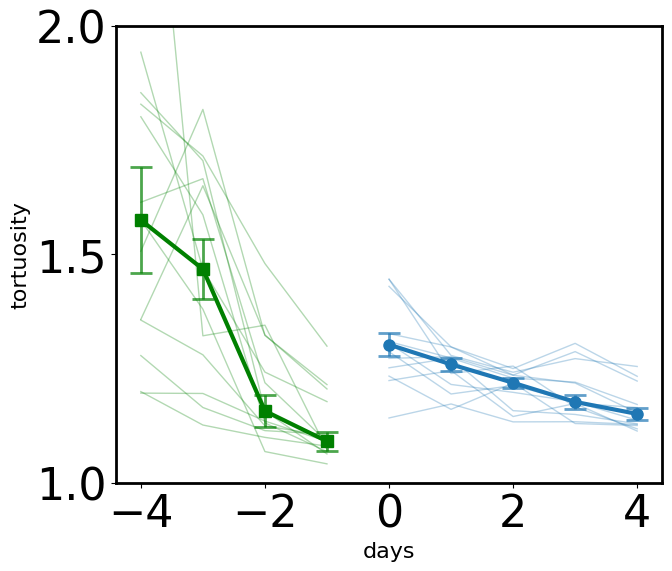


TORTUOSITY ANALYSIS SUMMARY

ANALYSIS: TRAINING CONDITION (Days -4 to 2)

1. DESCRIPTIVE STATISTICS (Mean ± SEM):
----------------------------------------
Day -4.0: 1.634 ± 0.116 (n=13)
Day -3.0: 1.467 ± 0.066 (n=13)
Day -2.0: 1.212 ± 0.034 (n=13)
Day -1.0: 1.124 ± 0.021 (n=13)

2. COMPARISON TO DAY 0:
----------------------------------------
Day -3.0 vs Day -4.0: diff = -0.167, t = 1.408, p = 0.1844
Day -2.0 vs Day -4.0: diff = -0.422, t = 4.028, p = 0.0017 **
Day -1.0 vs Day -4.0: diff = -0.511, t = 4.299, p = 0.0010 **

3. ONE-WAY ANOVA (across all days):
----------------------------------------
F-statistic = 11.278, p-value = 0.0000
✓ Significant differences exist between days

4. PAIRWISE COMPARISONS (Tukey's HSD):
----------------------------------------

Method 1 - Using summary():
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  -4.0   -3.0   -0.167 0.3376 -0.4294  0

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Create the plot (same as before)
fig, ax = plt.subplots(figsize=(7, 6))
plt.rcParams.update({'font.size': 16})

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter data to ranges
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Recalculate SEM based on individual animal medians
train_sem_by_animal = train_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']
train_population_stats = train_population_stats.merge(train_sem_by_animal, on='date_index')

light_sem_by_animal = light_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']
light_population_stats = light_population_stats.merge(light_sem_by_animal, on='date_index')

# Plot (same as before)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)
ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='tab:blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)
ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem_animal'], 
             color='tab:blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1,
             label='_nolegend_', zorder=1)

for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='tab:blue', alpha=0.3, linewidth=1, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)
ax.set_xticks([-4,-2,0,2,4])
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)

plt.tight_layout()
plt.show()

# ============================================================================
# SIMPLIFIED STATISTICAL ANALYSIS (WITH PROPER TUKEY HANDLING)
# ============================================================================

def simple_analysis(data, condition_name):
    """Simple analysis: mean ± SEM for each day and significant differences"""
    
    print(f"\n{'='*60}")
    print(f"ANALYSIS: {condition_name}")
    print('='*60)
    
    # 1. Calculate mean and SEM for each day
    print(f"\n1. DESCRIPTIVE STATISTICS (Mean ± SEM):")
    print("-" * 40)
    
    # Group by day and calculate stats
    daily_stats = data.groupby('date_index')['tortuosity'].agg(['mean', 'sem', 'count']).reset_index()
    
    for _, row in daily_stats.iterrows():
        print(f"Day {row['date_index']:2}: {row['mean']:.3f} ± {row['sem']:.3f} (n={int(row['count'])})")
    
    # 2. Check if we have enough data for ANOVA
    days = sorted(data['date_index'].unique())
    n_days = len(days)
    
    if n_days < 2:
        print(f"\n⚠️  Only {n_days} day(s) available - cannot perform ANOVA")
        return
    
    # 3. Simple repeated measures check: Compare each day to day 0 (or first day)
    print(f"\n2. COMPARISON TO DAY 0:")
    print("-" * 40)
    
    if 0 in days:
        ref_day = 0
        ref_day_name = "Day 0"
    else:
        ref_day = days[0]
        ref_day_name = f"Day {ref_day}"
    
    ref_data = data[data['date_index'] == ref_day]
    
    for day in days:
        if day != ref_day:
            day_data = data[data['date_index'] == day]
            
            # Find animals that have data on both days
            common_animals = set(ref_data['animal']).intersection(set(day_data['animal']))
            
            if len(common_animals) > 1:
                # Paired t-test for animals with both measurements
                ref_paired = ref_data[ref_data['animal'].isin(common_animals)].sort_values('animal')['tortuosity']
                day_paired = day_data[day_data['animal'].isin(common_animals)].sort_values('animal')['tortuosity']
                
                t_stat, p_val = stats.ttest_rel(ref_paired, day_paired)
                
                # Calculate mean difference
                mean_diff = np.mean(day_paired) - np.mean(ref_paired)
                
                print(f"Day {day} vs {ref_day_name}: diff = {mean_diff:.3f}, t = {t_stat:.3f}, p = {p_val:.4f}", end="")
                
                if p_val < 0.001:
                    print(" ***")
                elif p_val < 0.01:
                    print(" **")
                elif p_val < 0.05:
                    print(" *")
                else:
                    print()
            else:
                print(f"Day {day} vs {ref_day_name}: Not enough paired data (n={len(common_animals)})")
    
    # 4. One-way ANOVA to check if any days differ
    print(f"\n3. ONE-WAY ANOVA (across all days):")
    print("-" * 40)
    
    # Prepare data for ANOVA
    anova_data = []
    groups = []
    
    for day in days:
        day_values = data[data['date_index'] == day]['tortuosity'].values
        anova_data.extend(day_values)
        groups.extend([day] * len(day_values))
    
    # Perform one-way ANOVA
    anova_groups = [data[data['date_index'] == day]['tortuosity'].values for day in days]
    f_stat, p_anova = stats.f_oneway(*anova_groups)
    
    print(f"F-statistic = {f_stat:.3f}, p-value = {p_anova:.4f}")
    
    if p_anova < 0.05:
        print("✓ Significant differences exist between days")
        
        # 5. FIXED: Tukey's HSD for pairwise comparisons
        print(f"\n4. PAIRWISE COMPARISONS (Tukey's HSD):")
        print("-" * 40)
        
        tukey = pairwise_tukeyhsd(anova_data, groups, alpha=0.05)
        
        # Method 1: Use the built-in summary (simplest)
        print("\nMethod 1 - Using summary():")
        print(tukey.summary())
        
        # Method 2: Extract data properly (for your version of statsmodels)
        print("\nMethod 2 - Clean table of significant comparisons:")
        
        # Check what attributes are available
        print(f"Available attributes: {[attr for attr in dir(tukey) if not attr.startswith('_')]}")
        
        # Try different ways to access the results
        try:
            # Try accessing as a DataFrame
            results_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
            
            # Convert string columns to numeric where appropriate
            results_df['meandiff'] = pd.to_numeric(results_df['meandiff'])
            results_df['p-adj'] = pd.to_numeric(results_df['p-adj'])
            results_df['reject'] = results_df['reject'].astype(bool)
            
            # Filter for significant comparisons
            sig_results = results_df[results_df['reject']]
            
            if len(sig_results) > 0:
                print(f"\nFound {len(sig_results)} significant comparison(s):")
                for _, row in sig_results.iterrows():
                    print(f"  Day {row['group1']} vs Day {row['group2']}: " +
                          f"diff = {row['meandiff']:.3f}, p = {row['p-adj']:.4f}")
            else:
                print("No significant pairwise differences found")
                
        except Exception as e:
            print(f"Could not extract results as DataFrame: {e}")
            
            # Fallback: Parse the string summary
            print("\nParsing string output...")
            summary_str = str(tukey.summary())
            lines = summary_str.split('\n')
            
            # Skip header lines and find the table
            start_idx = None
            for i, line in enumerate(lines):
                if 'group1' in line and 'group2' in line:
                    start_idx = i
                    break
            
            if start_idx is not None:
                print("\nSignificant comparisons found in summary:")
                for line in lines[start_idx+1:]:
                    if line.strip() and 'True' in line:
                        parts = line.split()
                        if len(parts) >= 6:
                            group1 = parts[0]
                            group2 = parts[1]
                            try:
                                meandiff = float(parts[2])
                                p_adj = float(parts[4])
                                print(f"  Day {group1} vs Day {group2}: diff = {meandiff:.3f}, p = {p_adj:.4f}")
                            except:
                                print(f"  {line.strip()}")
    
    else:
        print("✗ No significant differences between days")
    
    # 6. Simple trend check
    print(f"\n5. LINEAR TREND:")
    print("-" * 40)
    
    # Calculate mean for each day
    day_means = data.groupby('date_index')['tortuosity'].mean().reset_index()
    
    if len(day_means) > 1:
        slope, intercept, r_value, p_trend, std_err = stats.linregress(
            day_means['date_index'], day_means['tortuosity']
        )
        
        print(f"Slope: {slope:.4f} (change per day)")
        print(f"R-squared: {r_value**2:.4f}")
        print(f"p-value: {p_trend:.4f}")
        
        if p_trend < 0.05:
            if slope > 0:
                print("✓ Significant increasing trend across days")
            else:
                print("✓ Significant decreasing trend across days")
        else:
            print("✗ No significant linear trend")
    
    print(f"\n{'='*60}\n")

# ============================================================================
# RUN ANALYSIS FOR BOTH CONDITIONS
# ============================================================================

print("\n" + "="*60)
print("TORTUOSITY ANALYSIS SUMMARY")
print("="*60)

# Analyze Training Condition
simple_analysis(train_animal_medians, "TRAINING CONDITION (Days -4 to 2)")

# Analyze Light/Dark Condition  
simple_analysis(light_animal_medians, "LIGHT/DARK CONDITION (Days -4 to 4)")

# ============================================================================
# SUMMARY TABLE (for easy copy-paste)
# ============================================================================

print("\n" + "="*60)
print("SUMMARY TABLE (Mean ± SEM)")
print("="*60)

print("\nTRAINING CONDITION:")
print("Day   Mean ± SEM      n")
print("-" * 30)

train_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['mean', 'sem', 'count']).reset_index()
for _, row in train_stats.iterrows():
    print(f"{row['date_index']:3}   {row['mean']:.3f} ± {row['sem']:.3f}   {int(row['count'])}")

print("\nLIGHT/DARK CONDITION:")
print("Day   Mean ± SEM      n")
print("-" * 30)

light_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['mean', 'sem', 'count']).reset_index()
for _, row in light_stats.iterrows():
    print(f"{row['date_index']:3}   {row['mean']:.3f} ± {row['sem']:.3f}   {int(row['count'])}")

# ============================================================================
# BONUS: COMPARE CONDITIONS AT OVERLAPPING DAYS
# ============================================================================

print("\n" + "="*60)
print("COMPARISON BETWEEN CONDITIONS")
print("="*60)

# Find days that exist in both conditions
train_days = set(train_animal_medians['date_index'].unique())
light_days = set(light_animal_medians['date_index'].unique())
common_days = sorted(list(train_days.intersection(light_days)))

if common_days:
    print(f"\nComparison at overlapping days:")
    print(f"{'Day':>5} {'Train Mean':>12} {'Light Mean':>12} {'p-value':>10}")
    print("-" * 45)
    
    for day in common_days:
        train_day_data = train_animal_medians[train_animal_medians['date_index'] == day]['tortuosity']
        light_day_data = light_animal_medians[light_animal_medians['date_index'] == day]['tortuosity']
        
        # Independent t-test (different animals in each condition)
        t_stat, p_val = stats.ttest_ind(train_day_data, light_day_data, equal_var=False)
        
        print(f"{day:5} {np.mean(train_day_data):12.3f} {np.mean(light_day_data):12.3f} {p_val:10.4f}", end="")
        
        if p_val < 0.001:
            print(" ***")
        elif p_val < 0.01:
            print(" **")
        elif p_val < 0.05:
            print(" *")
        else:
            print()
else:
    print("\nNo overlapping days between conditions")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

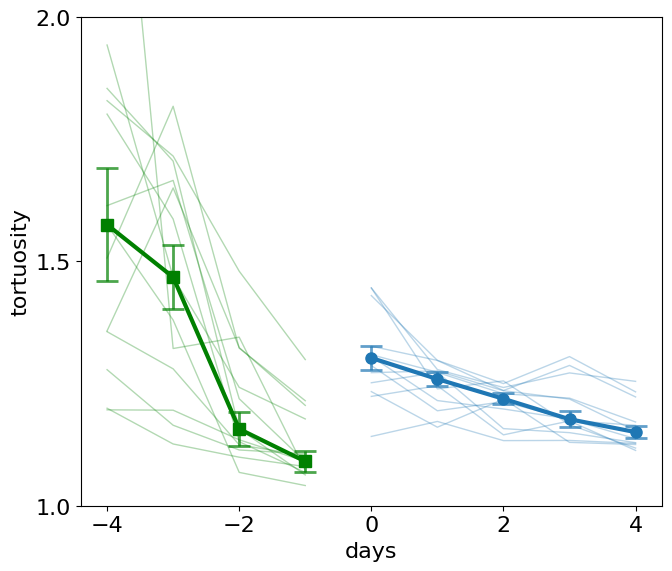

KRUSKAL-WALLIS TEST: EFFECT OF DAYS ON TORTUOSITY WITHIN EACH CONDITION
Using animal medians per day

ANALYZING TRAINING CONDITION

TRAINING CONDITION
Days analyzed: [-4.0, -3.0, -2.0, -1.0]
Total animals: 13

Animals per day:
  Day -4.0: 13 animals
  Day -3.0: 13 animals
  Day -2.0: 13 animals
  Day -1.0: 13 animals

--- Kruskal-Wallis Test Results ---
Kruskal-Wallis test: H(3) = 27.533, p = 0.0000
Effect size (epsilon squared): 0.511
Interpretation: ε² = 0.511
Significance: ***
Effect size magnitude: LARGE

--- POST-HOC PAIRWISE COMPARISONS ---
Performing pairwise comparisons between days...
Number of comparisons: 6
Bonferroni-corrected alpha: 0.008333

  Day -4.0 (Mdn=1.575, n=13) vs Day -3.0 (Mdn=1.468, n=13):
    U = 105.0, p = 0.3051, median diff = -0.107
    Effect size (rank-biserial): -0.243
    Not significant

  Day -4.0 (Mdn=1.575, n=13) vs Day -2.0 (Mdn=1.157, n=13):
    U = 151.0, p = 0.0007, median diff = -0.418
    Effect size (rank-biserial): -0.787
    SIGNIFICANT aft

In [38]:
# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
#train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0]).reset_index()
train_population_stats.columns = ['date_index', 'median', 'sem']

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0]).reset_index()
light_population_stats.columns = ['date_index', 'median', 'sem']

# Filter train data to only include date_index from -4 to 2
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4 (adding date_index 4)
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Plot train data (using original date_index)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Median', zorder=5)

ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='tab:blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Median', zorder=5)

ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem'], 
             color='tab:blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces with lines
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animal traces
for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1,
             label='_nolegend_', zorder=1)

# Plot light/dark individual animal traces
for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='tab:blue', alpha=0.3, linewidth=1, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks([-4,-2,0,2,4])
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)

plt.tight_layout()
plt.show()

# ============================================================================
# KRUSKAL-WALLIS AND POST-HOC TESTS FOR EACH CONDITION (USING MEDIANS)
# ============================================================================
print("="*80)
print("KRUSKAL-WALLIS TEST: EFFECT OF DAYS ON TORTUOSITY WITHIN EACH CONDITION")
print("Using animal medians per day")
print("="*80)

# Helper function for significance stars
def get_significance(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Function to perform Kruskal-Wallis and post-hoc tests
def analyze_day_effect_medians(data, condition_name):
    print(f"\n{'='*60}")
    print(f"{condition_name.upper()} CONDITION")
    print(f"{'='*60}")
    
    # Get unique days
    unique_days = sorted(data['date_index'].unique())
    print(f"Days analyzed: {unique_days}")
    print(f"Total animals: {data['animal'].nunique()}")
    
    # Check number of animals per day
    animals_per_day = data.groupby('date_index')['animal'].nunique()
    print("\nAnimals per day:")
    for day, n_animals in animals_per_day.items():
        print(f"  Day {day}: {n_animals} animals")
    
    # Collect data for Kruskal-Wallis
    day_groups = []
    for day in unique_days:
        day_data = data[data['date_index'] == day]['tortuosity'].values
        if len(day_data) > 0:
            day_groups.append(day_data)
    
    # Perform Kruskal-Wallis test (non-parametric alternative to ANOVA)
    print(f"\n--- Kruskal-Wallis Test Results ---")
    
    if len(day_groups) >= 2 and all(len(g) > 0 for g in day_groups):
        # Perform Kruskal-Wallis test
        h_stat, p_value = stats.kruskal(*day_groups)
        
        # Calculate degrees of freedom
        k = len(day_groups)  # number of groups
        df = k - 1
        
        # Calculate effect size (epsilon squared)
        N = sum(len(g) for g in day_groups)  # total observations
        epsilon_squared = (h_stat - df) / (N - k)
        
        print(f"Kruskal-Wallis test: H({df}) = {h_stat:.3f}, p = {p_value:.4f}")
        print(f"Effect size (epsilon squared): {epsilon_squared:.3f}")
        print(f"Interpretation: ε² = {epsilon_squared:.3f}")
        print(f"Significance: {get_significance(p_value)}")
        
        # Effect size interpretation for epsilon squared
        if epsilon_squared >= 0.14:
            effect_size_desc = "LARGE"
        elif epsilon_squared >= 0.06:
            effect_size_desc = "MEDIUM"
        elif epsilon_squared >= 0.01:
            effect_size_desc = "SMALL"
        else:
            effect_size_desc = "NEGLIGIBLE"
        print(f"Effect size magnitude: {effect_size_desc}")
        
        # Post-hoc tests if Kruskal-Wallis is significant
        if p_value < 0.05:
            print(f"\n--- POST-HOC PAIRWISE COMPARISONS ---")
            print("Performing pairwise comparisons between days...")
            
            # Perform pairwise Mann-Whitney U tests with Bonferroni correction
            from itertools import combinations
            
            pairs = list(combinations(unique_days, 2))
            n_comparisons = len(pairs)
            bonferroni_alpha = 0.05 / n_comparisons if n_comparisons > 0 else 0.05
            
            print(f"Number of comparisons: {n_comparisons}")
            print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.6f}")
            
            significant_pairs = []
            
            for day1, day2 in pairs:
                data1 = data[data['date_index'] == day1]['tortuosity'].values
                data2 = data[data['date_index'] == day2]['tortuosity'].values
                
                if len(data1) > 0 and len(data2) > 0:
                    # Calculate medians
                    median1 = np.median(data1)
                    median2 = np.median(data2)
                    median_diff = median2 - median1
                    
                    # Perform Mann-Whitney U test
                    u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                    
                    print(f"\n  Day {day1} (Mdn={median1:.3f}, n={len(data1)}) vs Day {day2} (Mdn={median2:.3f}, n={len(data2)}):")
                    print(f"    U = {u_stat:.1f}, p = {p_val:.4f}, median diff = {median_diff:.3f}")
                    
                    # Calculate rank-biserial correlation (effect size)
                    n1, n2 = len(data1), len(data2)
                    rbc = 1 - (2 * u_stat) / (n1 * n2)  # rank-biserial correlation
                    print(f"    Effect size (rank-biserial): {rbc:.3f}")
                    
                    # Check significance with Bonferroni correction
                    if p_val < bonferroni_alpha:
                        print(f"    SIGNIFICANT after Bonferroni correction (p < {bonferroni_alpha:.6f})")
                        significant_pairs.append((day1, day2, median_diff, p_val, rbc))
                    elif p_val < 0.05:
                        print(f"    Significant at p < 0.05 but NOT after Bonferroni correction")
                    else:
                        print(f"    Not significant")
            
            # Summary of significant findings
            if significant_pairs:
                print(f"\nSUMMARY OF SIGNIFICANT DIFFERENCES (Bonferroni-corrected):")
                for day1, day2, median_diff, p_val, rbc in significant_pairs:
                    direction = "increase" if median_diff > 0 else "decrease"
                    effect_magnitude = "large" if abs(rbc) >= 0.5 else "medium" if abs(rbc) >= 0.3 else "small"
                    print(f"  Day {day1} → Day {day2}: {abs(median_diff):.3f} {direction} (p = {p_val:.6f}, rbc = {rbc:.3f} [{effect_magnitude}])")
            else:
                print(f"\nNo significant differences after Bonferroni correction")
        
        else:
            print(f"\nKruskal-Wallis not significant (p = {p_value:.4f}), no post-hoc tests performed.")
    
    else:
        print("Not enough data for Kruskal-Wallis (need at least 2 groups with data)")
    
    # Calculate descriptive statistics for each day (using medians)
    print(f"\n--- DESCRIPTIVE STATISTICS BY DAY (MEDIANS) ---")
    
    # Calculate median and IQR for each day
    day_stats = []
    for day in unique_days:
        day_data = data[data['date_index'] == day]['tortuosity'].values
        if len(day_data) > 0:
            median = np.median(day_data)
            q1 = np.percentile(day_data, 25)
            q3 = np.percentile(day_data, 75)
            iqr = q3 - q1
            n = len(day_data)
            day_stats.append({
                'day': day,
                'median': median,
                'q1': q1,
                'q3': q3,
                'iqr': iqr,
                'n': n
            })
    
    day_stats_df = pd.DataFrame(day_stats)
    
    print(f"{'Day':>6} {'Median':>8} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'n':>6}")
    print("-" * 50)
    for _, row in day_stats_df.iterrows():
        print(f"{row['day']:6f} {row['median']:8.3f} {row['q1']:8.3f} {row['q3']:8.3f} {row['iqr']:8.3f} {row['n']:6.0f}")
    
    return day_stats_df

# Analyze training condition using medians
print("\n" + "="*80)
print("ANALYZING TRAINING CONDITION")
print("="*80)
train_day_stats = analyze_day_effect_medians(train_animal_medians, "Training")

# Analyze light/dark condition using medians
print("\n" + "="*80)
print("ANALYZING LIGHT/DARK CONDITION")
print("="*80)
light_day_stats = analyze_day_effect_medians(light_animal_medians, "Light/Dark")

# ============================================================================
# COMPARISON BETWEEN CONDITIONS USING MEDIANS
# ============================================================================
print("\n" + "="*80)
print("COMPARISON BETWEEN TRAINING AND LIGHT/DARK CONDITIONS")
print("Using overall animal medians")
print("="*80)

# Calculate overall animal medians across all days
train_animal_overall = train_animal_medians.groupby('animal')['tortuosity'].median().reset_index()
train_animal_overall.columns = ['animal', 'median_tortuosity_train']
train_animal_overall['condition'] = 'train'

light_animal_overall = light_animal_medians.groupby('animal')['tortuosity'].median().reset_index()
light_animal_overall.columns = ['animal', 'median_tortuosity_light']
light_animal_overall['condition'] = 'light'

# Find animals that appear in both datasets
common_animals = set(train_animal_overall['animal']).intersection(set(light_animal_overall['animal']))

print(f"\nOverall Animal Statistics:")
print(f"Training animals: {len(train_animal_overall)}")
print(f"Light/Dark animals: {len(light_animal_overall)}")
print(f"Animals in both conditions: {len(common_animals)}")

# Calculate overall condition medians
train_overall_median = np.median(train_animal_overall['median_tortuosity_train'])
train_q1 = np.percentile(train_animal_overall['median_tortuosity_train'], 25)
train_q3 = np.percentile(train_animal_overall['median_tortuosity_train'], 75)
train_iqr = train_q3 - train_q1

light_overall_median = np.median(light_animal_overall['median_tortuosity_light'])
light_q1 = np.percentile(light_animal_overall['median_tortuosity_light'], 25)
light_q3 = np.percentile(light_animal_overall['median_tortuosity_light'], 75)
light_iqr = light_q3 - light_q1

print(f"\nOverall Condition Medians:")
print(f"Training:  Median = {train_overall_median:.3f}, IQR = [{train_q1:.3f}, {train_q3:.3f}], n={len(train_animal_overall)}")
print(f"Light/Dark: Median = {light_overall_median:.3f}, IQR = [{light_q1:.3f}, {light_q3:.3f}], n={len(light_animal_overall)}")

# 1. Mann-Whitney U test (non-parametric independent test)
print(f"\n1. MANN-WHITNEY U TEST (non-parametric independent):")
u_stat, p_value_mw = stats.mannwhitneyu(
    train_animal_overall['median_tortuosity_train'], 
    light_animal_overall['median_tortuosity_light'],
    alternative='two-sided'
)

# Calculate effect size (rank-biserial correlation for independent samples)
n1 = len(train_animal_overall)
n2 = len(light_animal_overall)
effect_size_mw = 1 - (2 * u_stat) / (n1 * n2)

print(f"U = {u_stat:.0f}, p = {p_value_mw:.4f}")
print(f"Effect size (rank-biserial correlation): {effect_size_mw:.3f}")
print(f"Significance: {get_significance(p_value_mw)}")

# 2. Paired tests if we have common animals
if len(common_animals) >= 2:
    print(f"\n2. PAIRED TESTS (common animals only, n={len(common_animals)}):")
    
    # Create combined dataframe for common animals
    combined_data = []
    for animal in common_animals:
        train_median = train_animal_overall[train_animal_overall['animal'] == animal]['median_tortuosity_train'].values[0]
        light_median = light_animal_overall[light_animal_overall['animal'] == animal]['median_tortuosity_light'].values[0]
        combined_data.append({
            'animal': animal,
            'train_median': train_median,
            'light_median': light_median,
            'difference': light_median - train_median
        })
    
    combined_df = pd.DataFrame(combined_data)
    
    # 2a. Wilcoxon signed-rank test (non-parametric paired test)
    print(f"\n   a) Wilcoxon signed-rank test (non-parametric paired):")
    
    train_common = combined_df['train_median'].values
    light_common = combined_df['light_median'].values
    
    try:
        w_stat, p_value_wilcoxon = stats.wilcoxon(light_common, train_common, 
                                                  zero_method='pratt', 
                                                  correction=True, 
                                                  mode='auto')
        
        # Calculate statistics
        differences = light_common - train_common
        median_diff = np.median(differences)
        q1_diff = np.percentile(differences, 25)
        q3_diff = np.percentile(differences, 75)
        
        n_pairs = len(differences)
        n_pos = np.sum(differences > 0)
        n_neg = np.sum(differences < 0)
        n_zero = np.sum(differences == 0)
        
        print(f"      W = {w_stat:.1f}, p = {p_value_wilcoxon:.4f}")
        print(f"      Median difference (Light - Train): {median_diff:.3f}")
        print(f"      IQR of differences: [{q1_diff:.3f}, {q3_diff:.3f}]")
        print(f"      N pairs = {n_pairs}")
        print(f"      Positive differences (Light > Train): {n_pos}")
        print(f"      Negative differences (Light < Train): {n_neg}")
        print(f"      Zero differences: {n_zero}")
        print(f"      Significance: {get_significance(p_value_wilcoxon)}")
        
    except Exception as e:
        print(f"      Error in Wilcoxon test: {e}")
        
else:
    print(f"\n2. PAIRED TESTS: Not enough common animals (need ≥2, found {len(common_animals)})")

# 3. Calculate Hodges-Lehmann estimator for median difference
print(f"\n3. HODGES-LEHMANN ESTIMATOR (median difference):")
# Calculate all pairwise differences between groups
all_differences = []
for x in train_animal_overall['median_tortuosity_train']:
    for y in light_animal_overall['median_tortuosity_light']:
        all_differences.append(y - x)

hl_estimator = np.median(all_differences)
hl_ci_lower = np.percentile(all_differences, 2.5)
hl_ci_upper = np.percentile(all_differences, 97.5)

print(f"   Hodges-Lehmann estimator: {hl_estimator:.3f}")
print(f"   95% CI: [{hl_ci_lower:.3f}, {hl_ci_upper:.3f}]")

print("\n" + "="*80)
print("SUMMARY OF NON-PARAMETRIC ANALYSES (USING MEDIANS)")
print("="*80)
print("Within-condition analyses:")
print("  - Kruskal-Wallis test: Tests if tortuosity differs across days")
print("  - Post-hoc: Pairwise Mann-Whitney U tests with Bonferroni correction")
print("  - Effect size: Epsilon squared for K-W, rank-biserial for pairwise")
print("\nBetween-condition analyses:")
print("  - Mann-Whitney U test: Compares overall medians between conditions")
print("  - Wilcoxon signed-rank: Paired test for common animals")
print("  - Hodges-Lehmann: Estimator of median difference with CI")
print("\nKey findings:")
print(f"  Training: Days {-4} to {2}, {len(train_animal_overall)} animals")
print(f"  Light/Dark: Days {-4} to {4}, {len(light_animal_overall)} animals")
print(f"  Common animals for paired tests: {len(common_animals)}")

In [43]:
combined_selected

,date_index,animal,tortuosity,condition,period,group
0,-2.0,G8CK1LN,1.114064,training,Late Training,training_day-2.0
1,-2.0,G8CK1LT,1.124552,training,Late Training,training_day-2.0
2,-2.0,G8CK1RT,1.134929,training,Late Training,training_day-2.0
3,-2.0,G8CK1TT,1.099301,training,Late Training,training_day-2.0
4,-2.0,G8CKLN,1.218931,training,Late Training,training_day-2.0
5,-2.0,G8CKLT,1.344922,training,Late Training,training_day-2.0
6,-2.0,G8CKRN,1.068203,training,Late Training,training_day-2.0
7,-2.0,G8CKRT,1.157080,training,Late Training,training_day-2.0
8,-2.0,G8CKTT,1.131031,training,Late Training,training_day-2.0
9,-2.0,J701LT,1.323602,training,Late Training,training_day-2.0


DATA PREPARATION

Available dates in training data: [-4.0, -3.0, -2.0, -1.0]
Available dates in light data: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

Selected training days (last 2): [-2, -1]
Selected light days (first 2): [3, 4]

Final dataset size: 52 rows

Data distribution:
condition   light  training
date_index                 
-2.0            0        13
-1.0            0        13
 3.0           13         0
 4.0           13         0

PART 1: TWO-WAY ANOVA - Last 2 Training Days vs First 2 Light Days

Two-way ANOVA Results:
                               sum_sq    df            F        PR(>F)
C(condition)                      NaN   1.0          NaN           NaN
C(date_index)               22.166517   3.0  1118.913538  6.436774e-35
C(condition):C(date_index)   0.152619   3.0     7.703827  7.831588e-03
Residual                     0.316972  48.0          NaN           NaN

Interpretation:
✗ No significant main effect of CONDITION
✓ Significant main effect of DAY - Values change acr

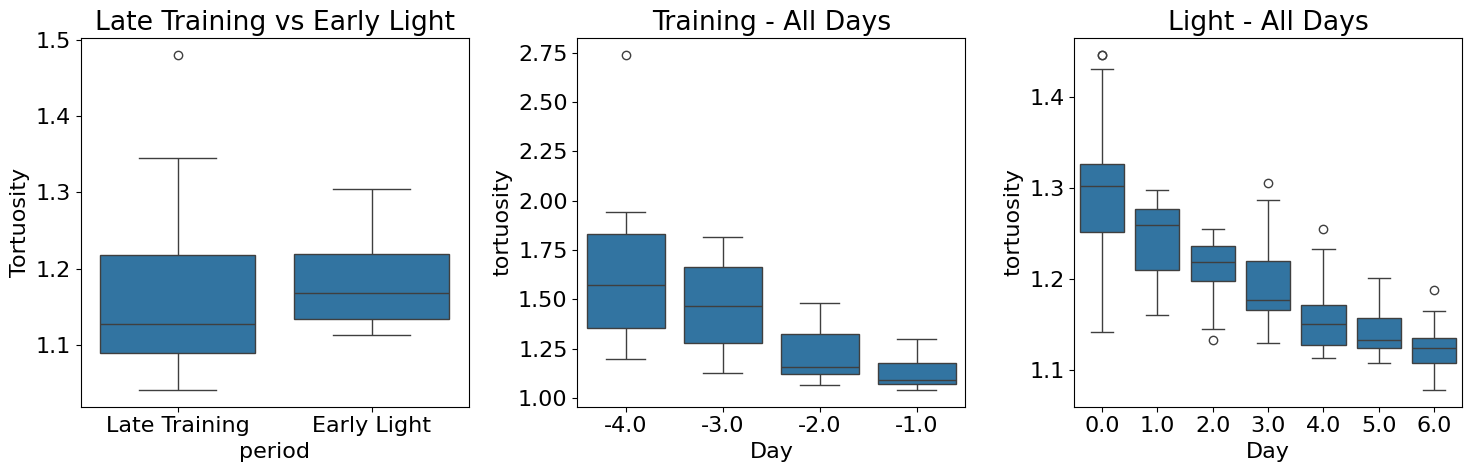

In [42]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import warnings
warnings.filterwarnings('ignore')

# First, let's prepare the data
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Process train data (filtering tortuosity <= 3 as in original)
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Process light/dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Select specific days of interest
# Last 2 days of training: days 1 and 2
# First 2 days of light: days -4 and -3 (or adjust based on your actual data)
print("\nAvailable dates in training data:", sorted(train_animal_medians['date_index'].unique()))
print("Available dates in light data:", sorted(light_animal_medians['date_index'].unique()))

# YOU MAY NEED TO ADJUST THESE BASED ON YOUR ACTUAL DATA
# Assuming training days go from negative to positive, with later days being later in training
# And light days start more negative
training_late_days = [-2,-1]  # Last 2 days of training (adjust if needed)
light_early_days = [3, 4]   # First 2 days of light/oa (adjust if needed)

print(f"\nSelected training days (last 2): {training_late_days}")
print(f"Selected light days (first 2): {light_early_days}")

# Filter data to only these days
train_selected = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)].copy()
light_selected = light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)].copy()

# Add condition labels
train_selected['condition'] = 'training'
light_selected['condition'] = 'light'

# Create a combined dataset for the 2x2 comparison
combined_selected = pd.concat([train_selected, light_selected], ignore_index=True)

# Create a period label (Late Training vs Early Light)
combined_selected['period'] = combined_selected['condition'].map({
    'training': 'Late Training', 
    'light': 'Early Light'
})

print(f"\nFinal dataset size: {len(combined_selected)} rows")
print("\nData distribution:")
print(pd.crosstab(combined_selected['date_index'], combined_selected['condition']))

# ============================================================================
# PART 1: TWO-WAY ANOVA - Late Training vs Early Light
# ============================================================================
print("\n" + "="*70)
print("PART 1: TWO-WAY ANOVA - Last 2 Training Days vs First 2 Light Days")
print("="*70)

# Two-way ANOVA: condition (training/light) × day (within each condition)
formula = 'tortuosity ~ C(condition) + C(date_index) + C(condition):C(date_index)'
model = ols(formula, data=combined_selected).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nTwo-way ANOVA Results:")
print(anova_table)
print("\nInterpretation:")
if anova_table.loc['C(condition)', 'PR(>F)'] < 0.05:
    print("✓ Significant main effect of CONDITION - Late Training differs from Early Light overall")
else:
    print("✗ No significant main effect of CONDITION")
    
if anova_table.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("✓ Significant main effect of DAY - Values change across the two days within each condition")
else:
    print("✗ No significant main effect of DAY")
    
if anova_table.loc['C(condition):C(date_index)', 'PR(>F)'] < 0.05:
    print("✓ Significant INTERACTION - The pattern across days differs between Training and Light")
else:
    print("✗ No significant INTERACTION")

# Post-hoc tests for the 2x2 comparison
print("\n" + "-"*50)
print("Post-hoc Tests for 2x2 Comparison")
print("-"*50)

# Create interaction groups for all 4 combinations
combined_selected['group'] = combined_selected['condition'] + '_day' + combined_selected['date_index'].astype(str)

# Tukey HSD on all groups
mc_all = MultiComparison(combined_selected['tortuosity'], combined_selected['group'])
tukey_all = mc_all.tukeyhsd(alpha=0.05)

print("\nAll pairwise comparisons (Tukey HSD):")
print(tukey_all.summary())

# Extract specifically the comparisons we care about
print("\n" + "-"*50)
print("FOCUSED COMPARISONS:")
print("-"*50)

# Comparison 1: Late Training vs Early Light (aggregated)
training_vals = combined_selected[combined_selected['condition'] == 'training']['tortuosity']
light_vals = combined_selected[combined_selected['condition'] == 'light']['tortuosity']

t_stat, p_val = stats.ttest_ind(training_vals, light_vals)
cohens_d = (training_vals.mean() - light_vals.mean()) / np.sqrt((training_vals.std()**2 + light_vals.std()**2)/2)

print(f"\n1. LATE TRAINING vs EARLY LIGHT (all days combined):")
print(f"   Late Training (days {training_late_days}): n={len(training_vals)}, mean={training_vals.mean():.4f} ± {training_vals.std():.4f}")
print(f"   Early Light (days {light_early_days}): n={len(light_vals)}, mean={light_vals.mean():.4f} ± {light_vals.std():.4f}")
print(f"   t-test p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
print(f"   Cohen's d: {cohens_d:.4f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small' if abs(cohens_d)>0.2 else 'negligible'} effect)")

# Comparison 2: Specific day-to-day comparisons
print(f"\n2. Day-by-day comparisons:")

for train_day in training_late_days:
    for light_day in light_early_days:
        train_day_vals = combined_selected[(combined_selected['condition'] == 'training') & 
                                           (combined_selected['date_index'] == train_day)]['tortuosity']
        light_day_vals = combined_selected[(combined_selected['condition'] == 'light') & 
                                           (combined_selected['date_index'] == light_day)]['tortuosity']
        
        if len(train_day_vals) > 0 and len(light_day_vals) > 0:
            t_stat, p_val = stats.ttest_ind(train_day_vals, light_day_vals)
            print(f"   Training Day {train_day} vs Light Day {light_day}: p={p_val:.4f} {'*' if p_val < 0.05 else ''}")

# ============================================================================
# PART 2: ONE-WAY ANOVA on TRAINING data only (across all days)
# ============================================================================
print("\n" + "="*70)
print("PART 2: ONE-WAY ANOVA - TRAINING CONDITION (across all days)")
print("="*70)

# Get all training days
training_all_days = sorted(train_animal_medians['date_index'].unique())
print(f"Training days analyzed: {training_all_days}")

# One-way ANOVA on training data
model_train = ols('tortuosity ~ C(date_index)', data=train_animal_medians).fit()
anova_train = sm.stats.anova_lm(model_train, typ=2)

print("\nOne-way ANOVA Results for Training:")
print(anova_train)

if anova_train.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("\n✓ Significant differences across training days")
    
    # Post-hoc tests for training
    print("\n" + "-"*50)
    print("Post-hoc Tests for Training (Tukey HSD)")
    print("-"*50)
    
    mc_train = MultiComparison(train_animal_medians['tortuosity'], 
                               train_animal_medians['date_index'])
    tukey_train = mc_train.tukeyhsd(alpha=0.05)
    
    print(tukey_train.summary())
    
    # Highlight specific comparison: last 2 days vs first 2 days of training
    if len(training_all_days) >= 4:
        first_two_train = training_all_days[:2]
        last_two_train = training_all_days[-2:]
        
        first_vals = train_animal_medians[train_animal_medians['date_index'].isin(first_two_train)]['tortuosity']
        last_vals = train_animal_medians[train_animal_medians['date_index'].isin(last_two_train)]['tortuosity']
        
        t_stat, p_val = stats.ttest_ind(first_vals, last_vals)
        print(f"\nFocused: First {first_two_train} vs Last {last_two_train} training days:")
        print(f"   First days mean: {first_vals.mean():.4f}")
        print(f"   Last days mean: {last_vals.mean():.4f}")
        print(f"   p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
else:
    print("\n✗ No significant differences across training days")

# ============================================================================
# PART 3: ONE-WAY ANOVA on LIGHT data only (across all days)
# ============================================================================
print("\n" + "="*70)
print("PART 3: ONE-WAY ANOVA - LIGHT CONDITION (across all days)")
print("="*70)

# Get all light days
light_all_days = sorted(light_animal_medians['date_index'].unique())
print(f"Light days analyzed: {light_all_days}")

# One-way ANOVA on light data
model_light = ols('tortuosity ~ C(date_index)', data=light_animal_medians).fit()
anova_light = sm.stats.anova_lm(model_light, typ=2)

print("\nOne-way ANOVA Results for Light:")
print(anova_light)

if anova_light.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("\n✓ Significant differences across light days")
    
    # Post-hoc tests for light
    print("\n" + "-"*50)
    print("Post-hoc Tests for Light (Tukey HSD)")
    print("-"*50)
    
    mc_light = MultiComparison(light_animal_medians['tortuosity'], 
                               light_animal_medians['date_index'])
    tukey_light = mc_light.tukeyhsd(alpha=0.05)
    
    print(tukey_light.summary())
    
    # Highlight specific comparison: first 2 days vs last 2 days of light
    if len(light_all_days) >= 4:
        first_two_light = light_all_days[:2]
        last_two_light = light_all_days[-2:]
        
        first_vals = light_animal_medians[light_animal_medians['date_index'].isin(first_two_light)]['tortuosity']
        last_vals = light_animal_medians[light_animal_medians['date_index'].isin(last_two_light)]['tortuosity']
        
        t_stat, p_val = stats.ttest_ind(first_vals, last_vals)
        print(f"\nFocused: First {first_two_light} vs Last {last_two_light} light days:")
        print(f"   First days mean: {first_vals.mean():.4f}")
        print(f"   Last days mean: {last_vals.mean():.4f}")
        print(f"   p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
else:
    print("\n✗ No significant differences across light days")

# ============================================================================
# SUMMARY OF FINDINGS
# ============================================================================
print("\n" + "="*70)
print("SUMMARY OF KEY FINDINGS")
print("="*70)

print("\n1. LATE TRAINING vs EARLY LIGHT:")
print(f"   {'✓ SIGNIFICANT' if p_val < 0.05 else '✗ NOT significant'} difference "
      f"(p={p_val:.4f}, d={cohens_d:.4f})")

print("\n2. TRAINING condition across days:")
if anova_train.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("   ✓ Significant variation across training days")
    # Find max and min days
    train_means = train_animal_medians.groupby('date_index')['tortuosity'].mean()
    print(f"   Range: {train_means.min():.4f} to {train_means.max():.4f}")
else:
    print("   ✗ No significant variation across training days")

print("\n3. LIGHT condition across days:")
if anova_light.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("   ✓ Significant variation across light days")
    light_means = light_animal_medians.groupby('date_index')['tortuosity'].mean()
    print(f"   Range: {light_means.min():.4f} to {light_means.max():.4f}")
else:
    print("   ✗ No significant variation across light days")

# Optional: Create visualization
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: Late Training vs Early Light
    ax1 = axes[0]
    sns.boxplot(data=combined_selected, x='period', y='tortuosity', ax=ax1)
    ax1.set_title('Late Training vs Early Light')
    ax1.set_ylabel('Tortuosity')
    
    # Plot 2: Training across all days
    ax2 = axes[1]
    sns.boxplot(data=train_animal_medians, x='date_index', y='tortuosity', ax=ax2)
    ax2.set_title('Training - All Days')
    ax2.set_xlabel('Day')
    
    # Plot 3: Light across all days
    ax3 = axes[2]
    sns.boxplot(data=light_animal_medians, x='date_index', y='tortuosity', ax=ax3)
    ax3.set_title('Light - All Days')
    ax3.set_xlabel('Day')
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("\nNote: Install matplotlib and seaborn for visualization")

In [47]:
combined_selected

,date_index,animal,tortuosity,condition,period,group
0,-2.0,G8CK1LN,1.114064,training,Late Training,training_day-2.0
1,-2.0,G8CK1LT,1.124552,training,Late Training,training_day-2.0
2,-2.0,G8CK1RT,1.134929,training,Late Training,training_day-2.0
3,-2.0,G8CK1TT,1.099301,training,Late Training,training_day-2.0
4,-2.0,G8CKLN,1.218931,training,Late Training,training_day-2.0
5,-2.0,G8CKLT,1.344922,training,Late Training,training_day-2.0
6,-2.0,G8CKRN,1.068203,training,Late Training,training_day-2.0
7,-2.0,G8CKRT,1.157080,training,Late Training,training_day-2.0
8,-2.0,G8CKTT,1.131031,training,Late Training,training_day-2.0
9,-2.0,J701LT,1.323602,training,Late Training,training_day-2.0


In [46]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import warnings
warnings.filterwarnings('ignore')

# First, let's prepare the data
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Process train data (filtering tortuosity <= 3 as in original)
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Process light/dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Define the day groupings
training_late_days = [-2, -1]  # Last 2 days of training
light_early_days = [0, 1]      # First 2 days of light/oa
light_late_days = [3, 4]       # Last 2 days of light/oa

# Full ranges for one-way analyses
training_all_days = [-4, -3, -2, -1]  # All training days
light_all_days = [0, 1, 2, 3, 4]      # All light days

print("\n" + "="*70)
print("DAY GROUPINGS")
print("="*70)
print(f"Training - All days: {training_all_days}")
print(f"Training - Late days: {training_late_days}")
print(f"Light - Early days: {light_early_days}")
print(f"Light - Late days: {light_late_days}")
print(f"Light - All days: {light_all_days}")

# ============================================================================
# PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS
# ============================================================================
print("\n" + "="*70)
print("PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS")
print("="*70)

# Function to choose appropriate non-parametric test
def non_parametric_test(data1, data2, paired=False):
    """
    Perform appropriate non-parametric test
    paired=True: Wilcoxon signed-rank test
    paired=False: Mann-Whitney U test
    """
    if paired:
        # Wilcoxon signed-rank test for paired data
        stat, p_value = stats.wilcoxon(data1, data2)
        test_name = "Wilcoxon signed-rank test"
    else:
        # Mann-Whitney U test for independent data
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney U test"
    
    return stat, p_value, test_name

# Comparison 1: Training Late vs Light Early
print("\n" + "-"*60)
print("COMPARISON 1: Training Late (-2,-1) vs Light Early (0,1)")
print("-"*60)

# Get the data
train_late_vals = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['tortuosity']
light_early_vals = light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)]['tortuosity']

# Check if we have paired data (same animals across conditions)
animals_train = set(train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['animal'])
animals_light = set(light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)]['animal'])
common_animals = animals_train.intersection(animals_light)

print(f"Animals in Training Late: {len(animals_train)}")
print(f"Animals in Light Early: {len(animals_light)}")
print(f"Common animals: {len(common_animals)}")

if len(common_animals) > 0 and len(common_animals) == min(len(animals_train), len(animals_light)):
    # Likely paired data - use Wilcoxon
    # Need to align data by animal
    print("\nUsing paired Wilcoxon signed-rank test (same animals)")
    
    # Create paired data
    paired_data = []
    for animal in common_animals:
        train_val = train_animal_medians[(train_animal_medians['animal'] == animal) & 
                                         (train_animal_medians['date_index'].isin(training_late_days))]['tortuosity'].mean()
        light_val = light_animal_medians[(light_animal_medians['animal'] == animal) & 
                                         (light_animal_medians['date_index'].isin(light_early_days))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'training': train_val, 'light': light_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_value, test_name = non_parametric_test(paired_df['training'], paired_df['light'], paired=True)
    
    # Calculate effect size (r = Z/√N)
    from scipy.stats import norm
    z_score = norm.ppf(p_value/2)  # Approximate z-score from p-value
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    print(f"\nResults:")
    print(f"  Training Late median: {paired_df['training'].median():.4f}")
    print(f"  Light Early median: {paired_df['light'].median():.4f}")
    print(f"  Test: {test_name}")
    print(f"  Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f} ({'large' if effect_size>0.5 else 'medium' if effect_size>0.3 else 'small' if effect_size>0.1 else 'negligible'})")
    
else:
    # Independent samples - use Mann-Whitney
    print("\nUsing Mann-Whitney U test (independent samples)")
    stat, p_value, test_name = non_parametric_test(train_late_vals, light_early_vals, paired=False)
    
    # Calculate effect size (r = Z/√N)
    from scipy.stats import norm
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(train_late_vals) + len(light_early_vals))
    
    print(f"\nResults:")
    print(f"  Training Late (n={len(train_late_vals)}): median={train_late_vals.median():.4f}, IQR={train_late_vals.quantile(0.75)-train_late_vals.quantile(0.25):.4f}")
    print(f"  Light Early (n={len(light_early_vals)}): median={light_early_vals.median():.4f}, IQR={light_early_vals.quantile(0.75)-light_early_vals.quantile(0.25):.4f}")
    print(f"  Test: {test_name}")
    print(f"  U statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")

# Comparison 2: Training Late vs Light Late
print("\n" + "-"*60)
print("COMPARISON 2: Training Late (-2,-1) vs Light Late (3,4)")
print("-"*60)

# Get the data
train_late_vals = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['tortuosity']
light_late_vals = light_animal_medians[light_animal_medians['date_index'].isin(light_late_days)]['tortuosity']

# Check for paired data
animals_train = set(train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['animal'])
animals_light = set(light_animal_medians[light_animal_medians['date_index'].isin(light_late_days)]['animal'])
common_animals = animals_train.intersection(animals_light)

if len(common_animals) > 0 and len(common_animals) == min(len(animals_train), len(animals_light)):
    # Paired data
    print("\nUsing paired Wilcoxon signed-rank test (same animals)")
    
    paired_data = []
    for animal in common_animals:
        train_val = train_animal_medians[(train_animal_medians['animal'] == animal) & 
                                         (train_animal_medians['date_index'].isin(training_late_days))]['tortuosity'].mean()
        light_val = light_animal_medians[(light_animal_medians['animal'] == animal) & 
                                         (light_animal_medians['date_index'].isin(light_late_days))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'training': train_val, 'light': light_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_value, test_name = non_parametric_test(paired_df['training'], paired_df['light'], paired=True)
    
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    print(f"\nResults:")
    print(f"  Training Late median: {paired_df['training'].median():.4f}")
    print(f"  Light Late median: {paired_df['light'].median():.4f}")
    print(f"  Test: {test_name}")
    print(f"  Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")
    
else:
    # Independent samples
    print("\nUsing Mann-Whitney U test (independent samples)")
    stat, p_value, test_name = non_parametric_test(train_late_vals, light_late_vals, paired=False)
    
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(train_late_vals) + len(light_late_vals))
    
    print(f"\nResults:")
    print(f"  Training Late (n={len(train_late_vals)}): median={train_late_vals.median():.4f}")
    print(f"  Light Late (n={len(light_late_vals)}): median={light_late_vals.median():.4f}")
    print(f"  Test: {test_name}")
    print(f"  U statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")

# ============================================================================
# PART 2: NON-PARAMETRIC ALTERNATIVE TO ANOVA - KRUSKAL-WALLIS TEST
# ============================================================================
print("\n" + "="*70)
print("PART 2: NON-PARAMETRIC TESTS FOR WITHIN-CONDITION COMPARISONS")
print("="*70)

# Function for Kruskal-Wallis (non-parametric alternative to one-way ANOVA)
def kruskal_wallis_with_posthoc(data, group_col, value_col, groups):
    """
    Perform Kruskal-Wallis test followed by Dunn's post-hoc test
    """
    # Prepare data for each group
    group_data = [data[data[group_col] == g][value_col].values for g in groups]
    
    # Kruskal-Wallis test
    h_stat, p_value = stats.kruskal(*group_data)
    
    print(f"\nKruskal-Wallis Test:")
    print(f"  H-statistic: {h_stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    
    if p_value < 0.05:
        print("\n  Significant differences found! Performing Dunn's post-hoc test:")
        
        # Dunn's post-hoc test (requires scikit-posthocs)
        try:
            import scikit_posthocs as sp
            dunn_results = sp.posthoc_dunn(data, val_col=value_col, group_col=group_col, p_adjust='bonferroni')
            print("\n  Dunn's post-hoc test p-values (Bonferroni corrected):")
            print(dunn_results.round(4))
            
            # Mark significant comparisons
            print("\n  Significant pairwise comparisons:")
            for i in range(len(groups)):
                for j in range(i+1, len(groups)):
                    if dunn_results.iloc[i, j] < 0.05:
                        print(f"    {groups[i]} vs {groups[j]}: p={dunn_results.iloc[i, j]:.4f} *")
        except ImportError:
            # Fallback to pairwise Mann-Whitney with Bonferroni correction
            print("  (scikit-posthocs not available, using pairwise Mann-Whitney with Bonferroni)")
            n_comparisons = len(groups) * (len(groups) - 1) / 2
            bonferroni_alpha = 0.05 / n_comparisons
            
            for i in range(len(groups)):
                for j in range(i+1, len(groups)):
                    u_stat, p_val = stats.mannwhitneyu(group_data[i], group_data[j], alternative='two-sided')
                    print(f"    {groups[i]} vs {groups[j]}: p={p_val:.4f} {'*' if p_val < bonferroni_alpha else ''} (Bonferroni threshold: {bonferroni_alpha:.4f})")
    
    return h_stat, p_value

# Within Training comparison
print("\n" + "-"*60)
print("WITHIN TRAINING: Days -4, -3, -2, -1")
print("-"*60)

training_full = train_animal_medians[train_animal_medians['date_index'].isin(training_all_days)].copy()
training_groups = sorted(training_full['date_index'].unique())

print(f"Groups: {training_groups}")
print(f"Sample sizes: {training_full.groupby('date_index').size().to_dict()}")

# Kruskal-Wallis test
h_train, p_train = kruskal_wallis_with_posthoc(training_full, 'date_index', 'tortuosity', training_groups)

# Specific comparison: Early (-4,-3) vs Late (-2,-1) Training
print("\n" + "-"*40)
print("FOCUSED: Early Training (-4,-3) vs Late Training (-2,-1)")
print("-"*40)

early_train = training_full[training_full['date_index'].isin([-4, -3])]['tortuosity']
late_train = training_full[training_full['date_index'].isin([-2, -1])]['tortuosity']

# Check if paired (same animals)
animals_early = set(training_full[training_full['date_index'].isin([-4, -3])]['animal'])
animals_late = set(training_full[training_full['date_index'].isin([-2, -1])]['animal'])
common = animals_early.intersection(animals_late)

if len(common) > 0 and len(common) == min(len(animals_early), len(animals_late)):
    # Paired test
    paired_data = []
    for animal in common:
        early_val = training_full[(training_full['animal'] == animal) & 
                                   (training_full['date_index'].isin([-4, -3]))]['tortuosity'].mean()
        late_val = training_full[(training_full['animal'] == animal) & 
                                  (training_full['date_index'].isin([-2, -1]))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'early': early_val, 'late': late_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_val = stats.wilcoxon(paired_df['early'], paired_df['late'])
    test_used = "Wilcoxon signed-rank"
    
    # Effect size
    z_score = norm.ppf(p_val/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
else:
    # Independent test
    stat, p_val = stats.mannwhitneyu(early_train, late_train, alternative='two-sided')
    test_used = "Mann-Whitney U"
    effect_size = None

print(f"Test used: {test_used}")
print(f"Early Training (n={len(early_train)}): median={early_train.median():.4f}, IQR={early_train.quantile(0.75)-early_train.quantile(0.25):.4f}")
print(f"Late Training (n={len(late_train)}): median={late_train.median():.4f}, IQR={late_train.quantile(0.75)-late_train.quantile(0.25):.4f}")
print(f"p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
if effect_size:
    print(f"Effect size (r): {effect_size:.4f}")

# Within Light comparison
print("\n" + "-"*60)
print("WITHIN LIGHT: Days 0, 1, 2, 3, 4")
print("-"*60)

light_full = light_animal_medians[light_animal_medians['date_index'].isin(light_all_days)].copy()
light_groups = sorted(light_full['date_index'].unique())

print(f"Groups: {light_groups}")
print(f"Sample sizes: {light_full.groupby('date_index').size().to_dict()}")

# Kruskal-Wallis test
h_light, p_light = kruskal_wallis_with_posthoc(light_full, 'date_index', 'tortuosity', light_groups)

# Specific comparison: Early (0,1) vs Late (3,4) Light
print("\n" + "-"*40)
print("FOCUSED: Early Light (0,1) vs Late Light (3,4)")
print("-"*40)

early_light = light_full[light_full['date_index'].isin([0, 1])]['tortuosity']
late_light = light_full[light_full['date_index'].isin([3, 4])]['tortuosity']

# Check if paired
animals_early = set(light_full[light_full['date_index'].isin([0, 1])]['animal'])
animals_late = set(light_full[light_full['date_index'].isin([3, 4])]['animal'])
common = animals_early.intersection(animals_late)

if len(common) > 0 and len(common) == min(len(animals_early), len(animals_late)):
    # Paired test
    paired_data = []
    for animal in common:
        early_val = light_full[(light_full['animal'] == animal) & 
                                (light_full['date_index'].isin([0, 1]))]['tortuosity'].mean()
        late_val = light_full[(light_full['animal'] == animal) & 
                               (light_full['date_index'].isin([3, 4]))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'early': early_val, 'late': late_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_val = stats.wilcoxon(paired_df['early'], paired_df['late'])
    test_used = "Wilcoxon signed-rank"
    
    z_score = norm.ppf(p_val/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
else:
    # Independent test
    stat, p_val = stats.mannwhitneyu(early_light, late_light, alternative='two-sided')
    test_used = "Mann-Whitney U"
    effect_size = None

print(f"Test used: {test_used}")
print(f"Early Light (n={len(early_light)}): median={early_light.median():.4f}")
print(f"Late Light (n={len(late_light)}): median={late_light.median():.4f}")
print(f"p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
if effect_size:
    print(f"Effect size (r): {effect_size:.4f}")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY OF NON-PARAMETRIC TEST RESULTS")
print("="*70)

summary_data = []

# Collect results for summary
comparisons = [
    ("Training Late vs Light Early", p1 if 'p1' in locals() else None),
    ("Training Late vs Light Late", p_value if 'p_value' in locals() and 'Comparison 2' else None),
    ("Training Early vs Late", p_val if 'p_val' in locals() and 'FOCUSED: Early Training' else None),
    ("Light Early vs Late", p_val if 'p_val' in locals() and 'FOCUSED: Early Light' else None)
]

print("\n{:<30} {:<10} {:<10}".format("Comparison", "p-value", "Significant"))
print("-" * 50)

# Note: You'll need to store p-values from each test in variables
# This is a template - you should save p-values from each test above

DATA PREPARATION

DAY GROUPINGS
Training - All days: [-4, -3, -2, -1]
Training - Late days: [-2, -1]
Light - Early days: [0, 1]
Light - Late days: [3, 4]
Light - All days: [0, 1, 2, 3, 4]

PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS

------------------------------------------------------------
COMPARISON 1: Training Late (-2,-1) vs Light Early (0,1)
------------------------------------------------------------
Animals in Training Late: 13
Animals in Light Early: 13
Common animals: 13

Using paired Wilcoxon signed-rank test (same animals)

Results:
  Training Late median: 1.1135
  Light Early median: 1.2741
  Test: Wilcoxon signed-rank test
  Statistic: 8.0000
  p-value: 0.0061 *
  Effect size (r): 0.7605 (large)

------------------------------------------------------------
COMPARISON 2: Training Late (-2,-1) vs Light Late (3,4)
------------------------------------------------------------

Using paired Wilcoxon signed-rank test (same animals)

Results:
  Training Late median: 1.

DATA PREPARATION

DAY GROUPINGS
Training - All days: [-4, -3, -2, -1]
Training - Late days: [-2, -1]
Light - Early days: [0, 1]
Light - Late days: [3, 4]
Light - All days: [0, 1, 2, 3, 4]

--------------------------------------------------
VERIFYING AVAILABLE DATES:
Available training dates: [-4.0, -3.0, -2.0, -1.0]
Available light dates: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

PART 1: TWO-WAY ANOVA - Training Late (-2,-1) vs Light Early (0,1)

Sample sizes - Training Late: 26
Sample sizes - Light Early: 25

Distribution:
condition   Light_Early  Training_Late
date_index                            
-2.0                  0             13
-1.0                  0             13
 0.0                 13              0
 1.0                 12              0

Two-way ANOVA Results - Training Late vs Light Early:
                                 sum_sq    df          F    PR(>F)
C(condition)                   0.143624   1.0  18.046101  0.000101
C(day_for_anova)               0.072785   1.0   9.14

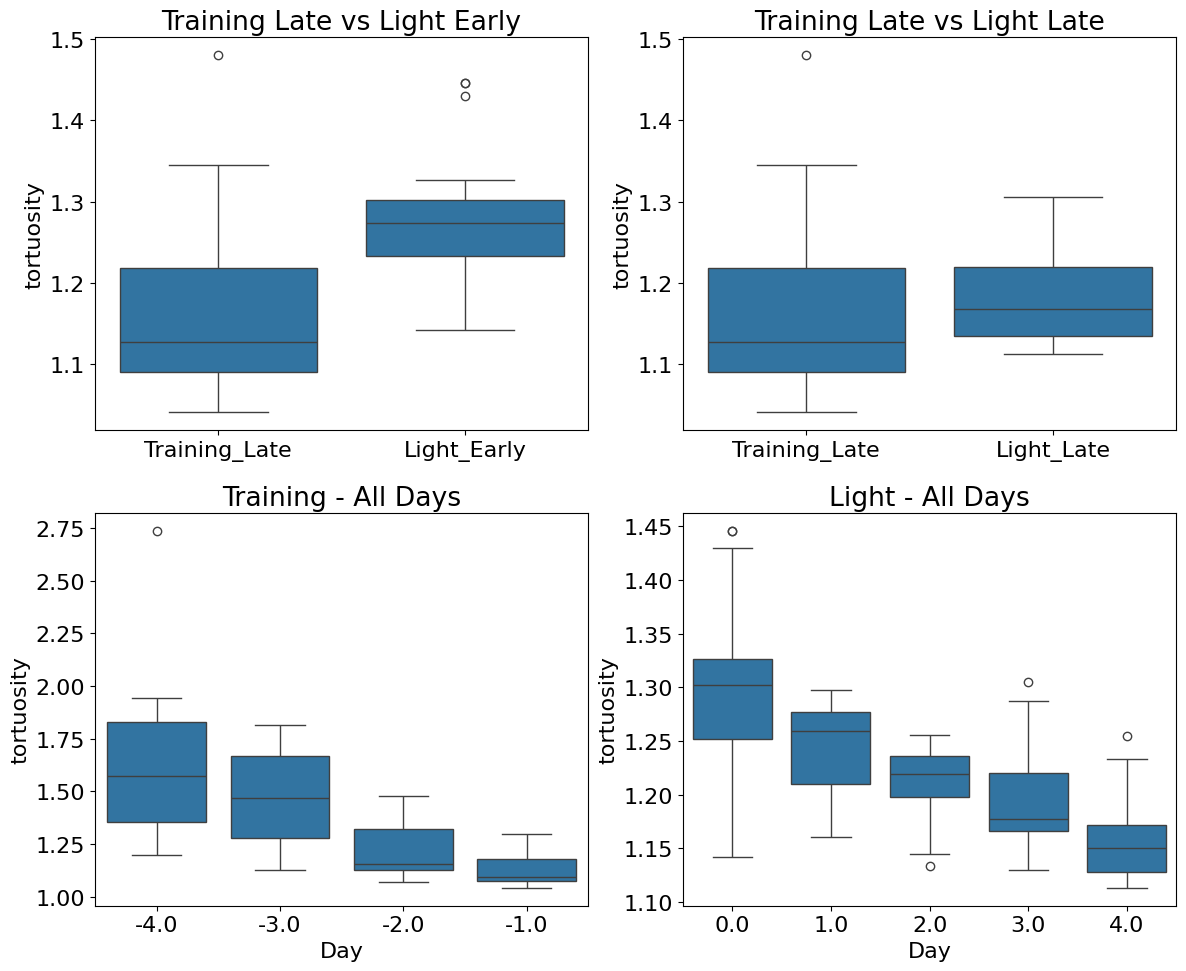

In [56]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import warnings
warnings.filterwarnings('ignore')

# First, let's prepare the data
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Process train data (filtering tortuosity <= 3 as in original)
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Process light/dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Define the day groupings based on your specifications
training_late_days = [-2, -1]  # Last 2 days of training
light_early_days = [0, 1]      # First 2 days of light/oa
light_late_days = [3, 4]       # Last 2 days of light/oa

# Full ranges for one-way ANOVAs
training_all_days = [-4, -3, -2, -1]  # All training days
light_all_days = [0, 1, 2, 3, 4]      # All light days

print("\n" + "="*70)
print("DAY GROUPINGS")
print("="*70)
print(f"Training - All days: {training_all_days}")
print(f"Training - Late days: {training_late_days}")
print(f"Light - Early days: {light_early_days}")
print(f"Light - Late days: {light_late_days}")
print(f"Light - All days: {light_all_days}")

# Check available dates
print("\n" + "-"*50)
print("VERIFYING AVAILABLE DATES:")
print(f"Available training dates: {sorted(train_animal_medians['date_index'].unique())}")
print(f"Available light dates: {sorted(light_animal_medians['date_index'].unique())}")

# ============================================================================
# PART 1: TWO-WAY ANOVA - Training Late vs Light Early
# ============================================================================
print("\n" + "="*70)
print("PART 1: TWO-WAY ANOVA - Training Late (-2,-1) vs Light Early (0,1)")
print("="*70)

# Filter data for this comparison
train_late = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)].copy()
light_early = light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)].copy()

# Add condition labels
train_late['condition'] = 'Training_Late'
light_early['condition'] = 'Light_Early'

# Combine data
combined_te = pd.concat([train_late, light_early], ignore_index=True)
combined_te = combined_te.copy()  # Make a copy to avoid warnings

# Recode the days: Training days -2,-1 become 0,1; Light days 0,1 become 2,3
combined_te['day_for_anova'] = combined_te.apply(
    lambda row: row['date_index'] + 2 if row['condition'] == 'Training_Late' 
    else row['date_index'],  # This maps Light 0,1 to 2,3
    axis=1
)
print(f"\nSample sizes - Training Late: {len(train_late)}")
print(f"Sample sizes - Light Early: {len(light_early)}")
print("\nDistribution:")
print(pd.crosstab(combined_te['date_index'], combined_te['condition']))

# Two-way ANOVA
formula = 'tortuosity ~ C(condition) + C(day_for_anova) + C(condition):C(day_for_anova)'
model_te = ols(formula, data=combined_te).fit()
anova_te = sm.stats.anova_lm(model_te, typ=2)

print("\nTwo-way ANOVA Results - Training Late vs Light Early:")
print(anova_te)

# Post-hoc tests
print("\n" + "-"*50)
print("Post-hoc Tests - Training Late vs Light Early")
print("-"*50)

# Overall condition comparison
train_vals = combined_te[combined_te['condition'] == 'Training_Late']['tortuosity']
light_vals = combined_te[combined_te['condition'] == 'Light_Early']['tortuosity']

t_stat, p_val = stats.ttest_ind(train_vals, light_vals)
cohens_d = (train_vals.mean() - light_vals.mean()) / np.sqrt((train_vals.std()**2 + light_vals.std()**2)/2)

print(f"\nOVERALL: Training Late vs Light Early:")
print(f"  Training Late (days {training_late_days}): n={len(train_vals)}, mean={train_vals.mean():.4f} ± {train_vals.std():.4f}")
print(f"  Light Early (days {light_early_days}): n={len(light_vals)}, mean={light_vals.mean():.4f} ± {light_vals.std():.4f}")
print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
print(f"  Cohen's d: {cohens_d:.4f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small' if abs(cohens_d)>0.2 else 'negligible'} effect)")

# Day-by-day comparisons
print(f"\nDAY-BY-DAY COMPARISONS:")
for train_day in training_late_days:
    for light_day in light_early_days:
        train_day_vals = combined_te[(combined_te['condition'] == 'Training_Late') & 
                                     (combined_te['date_index'] == train_day)]['tortuosity']
        light_day_vals = combined_te[(combined_te['condition'] == 'Light_Early') & 
                                     (combined_te['date_index'] == light_day)]['tortuosity']
        
        t_stat, p_val = stats.ttest_ind(train_day_vals, light_day_vals)
        print(f"  Training Day {train_day} vs Light Day {light_day}: p={p_val:.4f} {'*' if p_val < 0.05 else ''}")

# ============================================================================
# PART 2: TWO-WAY ANOVA - Training Late vs Light Late
# ============================================================================
print("\n" + "="*70)
print("PART 2: TWO-WAY ANOVA - Training Late (-2,-1) vs Light Late (3,4)")
print("="*70)

# Filter data for this comparison
train_late = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)].copy()
light_late = light_animal_medians[light_animal_medians['date_index'].isin(light_late_days)].copy()

# Add condition labels
train_late['condition'] = 'Training_Late'
light_late['condition'] = 'Light_Late'

# Combine data
combined_tl = pd.concat([train_late, light_late], ignore_index=True)
combined_tl = combined_tl.copy()  # Make a copy to avoid warnings

# Recode the days: Training days -2,-1 become 0,1; Light days 0,1 become 2,3
combined_tl['day_for_anova'] = combined_tl.apply(
    lambda row: row['date_index'] + 5 if row['condition'] == 'Training_Late' 
    else row['date_index'],  # This maps Light 0,1 to 2,3
    axis=1
)

print(f"\nSample sizes - Training Late: {len(train_late)}")
print(f"Sample sizes - Light Late: {len(light_late)}")
print("\nDistribution:")
print(pd.crosstab(combined_tl['date_index'], combined_tl['condition']))

# Two-way ANOVA
model_tl = ols(formula, data=combined_tl).fit()
anova_tl = sm.stats.anova_lm(model_tl, typ=2)

print("\nTwo-way ANOVA Results - Training Late vs Light Late:")
print(anova_tl)

# Post-hoc tests
print("\n" + "-"*50)
print("Post-hoc Tests - Training Late vs Light Late")
print("-"*50)

# Overall condition comparison
train_vals = combined_tl[combined_tl['condition'] == 'Training_Late']['tortuosity']
light_vals = combined_tl[combined_tl['condition'] == 'Light_Late']['tortuosity']

t_stat, p_val = stats.ttest_ind(train_vals, light_vals)
cohens_d = (train_vals.mean() - light_vals.mean()) / np.sqrt((train_vals.std()**2 + light_vals.std()**2)/2)

print(f"\nOVERALL: Training Late vs Light Late:")
print(f"  Training Late (days {training_late_days}): n={len(train_vals)}, mean={train_vals.mean():.4f} ± {train_vals.std():.4f}")
print(f"  Light Late (days {light_late_days}): n={len(light_vals)}, mean={light_vals.mean():.4f} ± {light_vals.std():.4f}")
print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
print(f"  Cohen's d: {cohens_d:.4f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small' if abs(cohens_d)>0.2 else 'negligible'} effect)")

# Day-by-day comparisons
print(f"\nDAY-BY-DAY COMPARISONS:")
for train_day in training_late_days:
    for light_day in light_late_days:
        train_day_vals = combined_tl[(combined_tl['condition'] == 'Training_Late') & 
                                     (combined_tl['date_index'] == train_day)]['tortuosity']
        light_day_vals = combined_tl[(combined_tl['condition'] == 'Light_Late') & 
                                     (combined_tl['date_index'] == light_day)]['tortuosity']
        
        t_stat, p_val = stats.ttest_ind(train_day_vals, light_day_vals)
        print(f"  Training Day {train_day} vs Light Day {light_day}: p={p_val:.4f} {'*' if p_val < 0.05 else ''}")

# ============================================================================
# PART 3: ONE-WAY ANOVA - TRAINING (all days: -4,-3,-2,-1)
# ============================================================================
print("\n" + "="*70)
print("PART 3: ONE-WAY ANOVA - TRAINING CONDITION (Days -4,-3,-2,-1)")
print("="*70)

# Filter training data to specified days
training_full = train_animal_medians[train_animal_medians['date_index'].isin(training_all_days)].copy()

print(f"\nTraining days analyzed: {sorted(training_full['date_index'].unique())}")
print(f"Total samples: {len(training_full)}")
print("\nSamples per day:")
print(training_full.groupby('date_index').size())

# One-way ANOVA on training data
model_train = ols('tortuosity ~ C(date_index)', data=training_full).fit()
anova_train = sm.stats.anova_lm(model_train, typ=2)

print("\nOne-way ANOVA Results for Training:")
print(anova_train)

if anova_train.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("\n✓ Significant differences across training days")
    
    # Post-hoc tests for training
    print("\n" + "-"*50)
    print("Post-hoc Tests for Training (Tukey HSD)")
    print("-"*50)
    
    mc_train = MultiComparison(training_full['tortuosity'], 
                               training_full['date_index'])
    tukey_train = mc_train.tukeyhsd(alpha=0.05)
    
    print(tukey_train.summary())
    
    # Specific comparison: Early (-4,-3) vs Late (-2,-1) training
    early_train = training_full[training_full['date_index'].isin([-4, -3])]['tortuosity']
    late_train = training_full[training_full['date_index'].isin([-2, -1])]['tortuosity']
    
    t_stat, p_val = stats.ttest_ind(early_train, late_train)
    cohens_d = (late_train.mean() - early_train.mean()) / np.sqrt((early_train.std()**2 + late_train.std()**2)/2)
    
    print(f"\nFOCUSED: Early Training (-4,-3) vs Late Training (-2,-1):")
    print(f"  Early Training mean: {early_train.mean():.4f} ± {early_train.std():.4f}")
    print(f"  Late Training mean: {late_train.mean():.4f} ± {late_train.std():.4f}")
    print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
    print(f"  Cohen's d: {cohens_d:.4f}")
else:
    print("\n✗ No significant differences across training days")

# ============================================================================
# PART 4: ONE-WAY ANOVA - LIGHT (all days: 0,1,2,3,4)
# ============================================================================
print("\n" + "="*70)
print("PART 4: ONE-WAY ANOVA - LIGHT CONDITION (Days 0,1,2,3,4)")
print("="*70)

# Filter light data to specified days
light_full = light_animal_medians[light_animal_medians['date_index'].isin(light_all_days)].copy()

print(f"\nLight days analyzed: {sorted(light_full['date_index'].unique())}")
print(f"Total samples: {len(light_full)}")
print("\nSamples per day:")
print(light_full.groupby('date_index').size())

# One-way ANOVA on light data
model_light = ols('tortuosity ~ C(date_index)', data=light_full).fit()
anova_light = sm.stats.anova_lm(model_light, typ=2)

print("\nOne-way ANOVA Results for Light:")
print(anova_light)

if anova_light.loc['C(date_index)', 'PR(>F)'] < 0.05:
    print("\n✓ Significant differences across light days")
    
    # Post-hoc tests for light
    print("\n" + "-"*50)
    print("Post-hoc Tests for Light (Tukey HSD)")
    print("-"*50)
    
    mc_light = MultiComparison(light_full['tortuosity'], 
                               light_full['date_index'])
    tukey_light = mc_light.tukeyhsd(alpha=0.05)
    
    print(tukey_light.summary())
    
    # Specific comparison: Early (0,1) vs Late (3,4) light
    early_light = light_full[light_full['date_index'].isin([0, 1])]['tortuosity']
    late_light = light_full[light_full['date_index'].isin([3, 4])]['tortuosity']
    
    t_stat, p_val = stats.ttest_ind(early_light, late_light)
    cohens_d = (late_light.mean() - early_light.mean()) / np.sqrt((early_light.std()**2 + late_light.std()**2)/2)
    
    print(f"\nFOCUSED: Early Light (0,1) vs Late Light (3,4):")
    print(f"  Early Light mean: {early_light.mean():.4f} ± {early_light.std():.4f}")
    print(f"  Late Light mean: {late_light.mean():.4f} ± {late_light.std():.4f}")
    print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    
    # Also check middle days if needed
    if 2 in light_all_days:
        middle_light = light_full[light_full['date_index'] == 2]['tortuosity']
        print(f"\n  Day 2 mean: {middle_light.mean():.4f} ± {middle_light.std():.4f}")
else:
    print("\n✗ No significant differences across light days")

# ============================================================================
# PART 5: ADDITIONAL COMPARISONS - Training Late vs Light Middle (Day 2)
# ============================================================================
print("\n" + "="*70)
print("PART 5: ADDITIONAL COMPARISON - Training Late vs Light Day 2")
print("="*70)

if 2 in light_animal_medians['date_index'].unique():
    light_day2 = light_animal_medians[light_animal_medians['date_index'] == 2]['tortuosity']
    train_late_vals = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['tortuosity']
    
    t_stat, p_val = stats.ttest_ind(train_late_vals, light_day2)
    cohens_d = (train_late_vals.mean() - light_day2.mean()) / np.sqrt((train_late_vals.std()**2 + light_day2.std()**2)/2)
    
    print(f"\nTraining Late (days {training_late_days}) vs Light Day 2:")
    print(f"  Training Late mean: {train_late_vals.mean():.4f} ± {train_late_vals.std():.4f}")
    print(f"  Light Day 2 mean: {light_day2.mean():.4f} ± {light_day2.std():.4f}")
    print(f"  p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
    print(f"  Cohen's d: {cohens_d:.4f}")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY OF KEY FINDINGS")
print("="*70)

summary_data = []

# Comparison 1: Training Late vs Light Early
train_vals = combined_te[combined_te['condition'] == 'Training_Late']['tortuosity']
light_vals = combined_te[combined_te['condition'] == 'Light_Early']['tortuosity']
t_stat, p1 = stats.ttest_ind(train_vals, light_vals)
summary_data.append(['Training Late vs Light Early', 
                     f"{train_vals.mean():.3f} ± {train_vals.std():.3f}",
                     f"{light_vals.mean():.3f} ± {light_vals.std():.3f}",
                     f"{p1:.4f}", '*' if p1 < 0.05 else ''])

# Comparison 2: Training Late vs Light Late
train_vals = combined_tl[combined_tl['condition'] == 'Training_Late']['tortuosity']
light_vals = combined_tl[combined_tl['condition'] == 'Light_Late']['tortuosity']
t_stat, p2 = stats.ttest_ind(train_vals, light_vals)
summary_data.append(['Training Late vs Light Late', 
                     f"{train_vals.mean():.3f} ± {train_vals.std():.3f}",
                     f"{light_vals.mean():.3f} ± {light_vals.std():.3f}",
                     f"{p2:.4f}", '*' if p2 < 0.05 else ''])

# Training within comparison
early_train = training_full[training_full['date_index'].isin([-4, -3])]['tortuosity']
late_train = training_full[training_full['date_index'].isin([-2, -1])]['tortuosity']
t_stat, p3 = stats.ttest_ind(early_train, late_train)
summary_data.append(['Training Early vs Late', 
                     f"{early_train.mean():.3f} ± {early_train.std():.3f}",
                     f"{late_train.mean():.3f} ± {late_train.std():.3f}",
                     f"{p3:.4f}", '*' if p3 < 0.05 else ''])

# Light within comparison
early_light = light_full[light_full['date_index'].isin([0, 1])]['tortuosity']
late_light = light_full[light_full['date_index'].isin([3, 4])]['tortuosity']
t_stat, p4 = stats.ttest_ind(early_light, late_light)
summary_data.append(['Light Early vs Late', 
                     f"{early_light.mean():.3f} ± {early_light.std():.3f}",
                     f"{late_light.mean():.3f} ± {late_light.std():.3f}",
                     f"{p4:.4f}", '*' if p4 < 0.05 else ''])

# Create summary DataFrame
summary_df = pd.DataFrame(summary_data, 
                          columns=['Comparison', 'Group 1 (mean±sd)', 'Group 2 (mean±sd)', 'p-value', 'Sig'])
print("\n", summary_df.to_string(index=False))

# Optional: Visualization
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Training Late vs Light Early
    ax1 = axes[0, 0]
    sns.boxplot(data=combined_te, x='condition', y='tortuosity', ax=ax1)
    ax1.set_title('Training Late vs Light Early')
    ax1.set_xlabel('')
    
    # Plot 2: Training Late vs Light Late
    ax2 = axes[0, 1]
    sns.boxplot(data=combined_tl, x='condition', y='tortuosity', ax=ax2)
    ax2.set_title('Training Late vs Light Late')
    ax2.set_xlabel('')
    
    # Plot 3: Training across days
    ax3 = axes[1, 0]
    sns.boxplot(data=training_full, x='date_index', y='tortuosity', ax=ax3)
    ax3.set_title('Training - All Days')
    ax3.set_xlabel('Day')
    
    # Plot 4: Light across days
    ax4 = axes[1, 1]
    sns.boxplot(data=light_full, x='date_index', y='tortuosity', ax=ax4)
    ax4.set_title('Light - All Days')
    ax4.set_xlabel('Day')
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("\nNote: Install matplotlib and seaborn for visualization")

In [57]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import warnings
warnings.filterwarnings('ignore')

# Function to calculate standard error of the median
def median_sem(data):
    """
    Calculate standard error of the median
    Method: Based on Maritz-Jarrett method or bootstrap
    """
    data = np.array(data)
    n = len(data)
    
    if n < 2:
        return 0
    
    # Method 1: Using bootstrap for standard error of median
    n_bootstrap = 1000
    bootstrap_medians = []
    
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    # Standard error is the standard deviation of bootstrap medians
    sem_median = np.std(bootstrap_medians)
    
    return sem_median

# Alternative method using IQR (faster approximation)
def median_sem_iqr(data):
    """
    Approximate standard error of median using IQR
    SEM_median ≈ 1.58 * IQR / sqrt(n)
    This is an approximation assuming normal distribution
    """
    data = np.array(data)
    n = len(data)
    
    if n < 2:
        return 0
    
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Approximation formula
    sem_approx = 1.58 * iqr / np.sqrt(n)
    
    return sem_approx

# Function to calculate standard error of the mean (for comparison)
def mean_sem(data):
    """Calculate standard error of the mean"""
    data = np.array(data)
    n = len(data)
    
    if n < 2:
        return 0
    
    return np.std(data, ddof=1) / np.sqrt(n)

# First, let's prepare the data
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Process train data (filtering tortuosity <= 3 as in original)
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Process light/dark data
light_data = light_dark[light_dark.task == 'oa']
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Define the day groupings
training_late_days = [-2, -1]  # Last 2 days of training
light_early_days = [0, 1]      # First 2 days of light/oa
light_late_days = [3, 4]       # Last 2 days of light/oa

# Full ranges for one-way analyses
training_all_days = [-4, -3, -2, -1]  # All training days
light_all_days = [0, 1, 2, 3, 4]      # All light days

print("\n" + "="*70)
print("DAY GROUPINGS")
print("="*70)
print(f"Training - All days: {training_all_days}")
print(f"Training - Late days: {training_late_days}")
print(f"Light - Early days: {light_early_days}")
print(f"Light - Late days: {light_late_days}")
print(f"Light - All days: {light_all_days}")

# ============================================================================
# PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS
# ============================================================================
print("\n" + "="*70)
print("PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS")
print("="*70)

# Function to choose appropriate non-parametric test
def non_parametric_test(data1, data2, paired=False):
    """
    Perform appropriate non-parametric test
    paired=True: Wilcoxon signed-rank test
    paired=False: Mann-Whitney U test
    """
    if paired:
        # Wilcoxon signed-rank test for paired data
        stat, p_value = stats.wilcoxon(data1, data2)
        test_name = "Wilcoxon signed-rank test"
    else:
        # Mann-Whitney U test for independent data
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney U test"
    
    return stat, p_value, test_name

# Comparison 1: Training Late vs Light Early
print("\n" + "-"*60)
print("COMPARISON 1: Training Late (-2,-1) vs Light Early (0,1)")
print("-"*60)

# Get the data
train_late_vals = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['tortuosity']
light_early_vals = light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)]['tortuosity']

# Check if we have paired data (same animals across conditions)
animals_train = set(train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['animal'])
animals_light = set(light_animal_medians[light_animal_medians['date_index'].isin(light_early_days)]['animal'])
common_animals = animals_train.intersection(animals_light)

print(f"Animals in Training Late: {len(animals_train)}")
print(f"Animals in Light Early: {len(animals_light)}")
print(f"Common animals: {len(common_animals)}")

if len(common_animals) > 0 and len(common_animals) == min(len(animals_train), len(animals_light)):
    # Likely paired data - use Wilcoxon
    # Need to align data by animal
    print("\nUsing paired Wilcoxon signed-rank test (same animals)")
    
    # Create paired data
    paired_data = []
    for animal in common_animals:
        train_val = train_animal_medians[(train_animal_medians['animal'] == animal) & 
                                         (train_animal_medians['date_index'].isin(training_late_days))]['tortuosity'].mean()
        light_val = light_animal_medians[(light_animal_medians['animal'] == animal) & 
                                         (light_animal_medians['date_index'].isin(light_early_days))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'training': train_val, 'light': light_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_value, test_name = non_parametric_test(paired_df['training'], paired_df['light'], paired=True)
    
    # Calculate effect size (r = Z/√N)
    from scipy.stats import norm
    z_score = norm.ppf(p_value/2)  # Approximate z-score from p-value
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    # Calculate standard errors for medians
    train_sem_median = median_sem(paired_df['training'])
    light_sem_median = median_sem(paired_df['light'])
    
    print(f"\nResults:")
    print(f"  Training Late median: {paired_df['training'].median():.4f} ± {train_sem_median:.4f} (SEM of median)")
    print(f"  Light Early median: {paired_df['light'].median():.4f} ± {light_sem_median:.4f} (SEM of median)")
    print(f"  Test: {test_name}")
    print(f"  Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f} ({'large' if effect_size>0.5 else 'medium' if effect_size>0.3 else 'small' if effect_size>0.1 else 'negligible'})")
    
else:
    # Independent samples - use Mann-Whitney
    print("\nUsing Mann-Whitney U test (independent samples)")
    stat, p_value, test_name = non_parametric_test(train_late_vals, light_early_vals, paired=False)
    
    # Calculate effect size (r = Z/√N)
    from scipy.stats import norm
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(train_late_vals) + len(light_early_vals))
    
    # Calculate standard errors for medians
    train_sem_median = median_sem(train_late_vals)
    light_sem_median = median_sem(light_early_vals)
    
    # Calculate IQR for reference
    train_iqr = train_late_vals.quantile(0.75) - train_late_vals.quantile(0.25)
    light_iqr = light_early_vals.quantile(0.75) - light_early_vals.quantile(0.25)
    
    print(f"\nResults:")
    print(f"  Training Late (n={len(train_late_vals)}): median={train_late_vals.median():.4f} ± {train_sem_median:.4f} (SEM of median)")
    print(f"    IQR: {train_iqr:.4f}, Mean±SEM: {train_late_vals.mean():.4f}±{mean_sem(train_late_vals):.4f}")
    print(f"  Light Early (n={len(light_early_vals)}): median={light_early_vals.median():.4f} ± {light_sem_median:.4f} (SEM of median)")
    print(f"    IQR: {light_iqr:.4f}, Mean±SEM: {light_early_vals.mean():.4f}±{mean_sem(light_early_vals):.4f}")
    print(f"  Test: {test_name}")
    print(f"  U statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")

# Comparison 2: Training Late vs Light Late
print("\n" + "-"*60)
print("COMPARISON 2: Training Late (-2,-1) vs Light Late (3,4)")
print("-"*60)

# Get the data
train_late_vals = train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['tortuosity']
light_late_vals = light_animal_medians[light_animal_medians['date_index'].isin(light_late_days)]['tortuosity']

# Check for paired data
animals_train = set(train_animal_medians[train_animal_medians['date_index'].isin(training_late_days)]['animal'])
animals_light = set(light_animal_medians[light_animal_medians['date_index'].isin(light_late_days)]['animal'])
common_animals = animals_train.intersection(animals_light)

if len(common_animals) > 0 and len(common_animals) == min(len(animals_train), len(animals_light)):
    # Paired data
    print("\nUsing paired Wilcoxon signed-rank test (same animals)")
    
    paired_data = []
    for animal in common_animals:
        train_val = train_animal_medians[(train_animal_medians['animal'] == animal) & 
                                         (train_animal_medians['date_index'].isin(training_late_days))]['tortuosity'].mean()
        light_val = light_animal_medians[(light_animal_medians['animal'] == animal) & 
                                         (light_animal_medians['date_index'].isin(light_late_days))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'training': train_val, 'light': light_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_value, test_name = non_parametric_test(paired_df['training'], paired_df['light'], paired=True)
    
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    # Calculate standard errors for medians
    train_sem_median = median_sem(paired_df['training'])
    light_sem_median = median_sem(paired_df['light'])
    
    print(f"\nResults:")
    print(f"  Training Late median: {paired_df['training'].median():.4f} ± {train_sem_median:.4f} (SEM of median)")
    print(f"  Light Late median: {paired_df['light'].median():.4f} ± {light_sem_median:.4f} (SEM of median)")
    print(f"  Test: {test_name}")
    print(f"  Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")
    
else:
    # Independent samples
    print("\nUsing Mann-Whitney U test (independent samples)")
    stat, p_value, test_name = non_parametric_test(train_late_vals, light_late_vals, paired=False)
    
    z_score = norm.ppf(p_value/2)
    effect_size = abs(z_score) / np.sqrt(len(train_late_vals) + len(light_late_vals))
    
    # Calculate standard errors for medians
    train_sem_median = median_sem(train_late_vals)
    light_sem_median = median_sem(light_late_vals)
    
    print(f"\nResults:")
    print(f"  Training Late (n={len(train_late_vals)}): median={train_late_vals.median():.4f} ± {train_sem_median:.4f} (SEM of median)")
    print(f"  Light Late (n={len(light_late_vals)}): median={light_late_vals.median():.4f} ± {light_sem_median:.4f} (SEM of median)")
    print(f"  Test: {test_name}")
    print(f"  U statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    print(f"  Effect size (r): {effect_size:.4f}")

# ============================================================================
# PART 2: NON-PARAMETRIC ALTERNATIVE TO ANOVA - KRUSKAL-WALLIS TEST
# ============================================================================
print("\n" + "="*70)
print("PART 2: NON-PARAMETRIC TESTS FOR WITHIN-CONDITION COMPARISONS")
print("="*70)

# Function for Kruskal-Wallis (non-parametric alternative to one-way ANOVA)
def kruskal_wallis_with_posthoc(data, group_col, value_col, groups):
    """
    Perform Kruskal-Wallis test followed by Dunn's post-hoc test
    """
    # Prepare data for each group
    group_data = [data[data[group_col] == g][value_col].values for g in groups]
    
    # Display medians with SEM for each group
    print("\nGroup medians with SEM:")
    for i, g in enumerate(groups):
        median_val = np.median(group_data[i])
        sem_val = median_sem(group_data[i])
        n_val = len(group_data[i])
        print(f"  Day {g}: median={median_val:.4f} ± {sem_val:.4f} (SEM), n={n_val}")
    
    # Kruskal-Wallis test
    h_stat, p_value = stats.kruskal(*group_data)
    
    print(f"\nKruskal-Wallis Test:")
    print(f"  H-statistic: {h_stat:.4f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''}")
    
    if p_value < 0.05:
        print("\n  Significant differences found! Performing Dunn's post-hoc test:")
        
        # Dunn's post-hoc test (requires scikit-posthocs)
        try:
            import scikit_posthocs as sp
            dunn_results = sp.posthoc_dunn(data, val_col=value_col, group_col=group_col, p_adjust='bonferroni')
            print("\n  Dunn's post-hoc test p-values (Bonferroni corrected):")
            print(dunn_results.round(4))
            
            # Mark significant comparisons
            print("\n  Significant pairwise comparisons:")
            for i in range(len(groups)):
                for j in range(i+1, len(groups)):
                    if dunn_results.iloc[i, j] < 0.05:
                        print(f"    {groups[i]} vs {groups[j]}: p={dunn_results.iloc[i, j]:.4f} *")
        except ImportError:
            # Fallback to pairwise Mann-Whitney with Bonferroni correction
            print("  (scikit-posthocs not available, using pairwise Mann-Whitney with Bonferroni)")
            n_comparisons = len(groups) * (len(groups) - 1) / 2
            bonferroni_alpha = 0.05 / n_comparisons
            
            for i in range(len(groups)):
                for j in range(i+1, len(groups)):
                    u_stat, p_val = stats.mannwhitneyu(group_data[i], group_data[j], alternative='two-sided')
                    print(f"    {groups[i]} vs {groups[j]}: p={p_val:.4f} {'*' if p_val < bonferroni_alpha else ''} (Bonferroni threshold: {bonferroni_alpha:.4f})")
    
    return h_stat, p_value

# Within Training comparison
print("\n" + "-"*60)
print("WITHIN TRAINING: Days -4, -3, -2, -1")
print("-"*60)

training_full = train_animal_medians[train_animal_medians['date_index'].isin(training_all_days)].copy()
training_groups = sorted(training_full['date_index'].unique())

print(f"Groups: {training_groups}")
print(f"Sample sizes: {training_full.groupby('date_index').size().to_dict()}")

# Kruskal-Wallis test
h_train, p_train = kruskal_wallis_with_posthoc(training_full, 'date_index', 'tortuosity', training_groups)

# Specific comparison: Early (-4,-3) vs Late (-2,-1) Training
print("\n" + "-"*40)
print("FOCUSED: Early Training (-4,-3) vs Late Training (-2,-1)")
print("-"*40)

early_train = training_full[training_full['date_index'].isin([-4, -3])]['tortuosity']
late_train = training_full[training_full['date_index'].isin([-2, -1])]['tortuosity']

# Check if paired (same animals)
animals_early = set(training_full[training_full['date_index'].isin([-4, -3])]['animal'])
animals_late = set(training_full[training_full['date_index'].isin([-2, -1])]['animal'])
common = animals_early.intersection(animals_late)

if len(common) > 0 and len(common) == min(len(animals_early), len(animals_late)):
    # Paired test
    paired_data = []
    for animal in common:
        early_val = training_full[(training_full['animal'] == animal) & 
                                   (training_full['date_index'].isin([-4, -3]))]['tortuosity'].mean()
        late_val = training_full[(training_full['animal'] == animal) & 
                                  (training_full['date_index'].isin([-2, -1]))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'early': early_val, 'late': late_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_val = stats.wilcoxon(paired_df['early'], paired_df['late'])
    test_used = "Wilcoxon signed-rank"
    
    # Effect size
    z_score = norm.ppf(p_val/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    # Calculate SEM for medians
    early_sem = median_sem(paired_df['early'])
    late_sem = median_sem(paired_df['late'])
else:
    # Independent test
    stat, p_val = stats.mannwhitneyu(early_train, late_train, alternative='two-sided')
    test_used = "Mann-Whitney U"
    effect_size = None
    early_sem = median_sem(early_train)
    late_sem = median_sem(late_train)

print(f"Test used: {test_used}")
print(f"Early Training (n={len(early_train)}): median={early_train.median():.4f} ± {early_sem:.4f} (SEM of median)")
print(f"  IQR: {early_train.quantile(0.75)-early_train.quantile(0.25):.4f}")
print(f"Late Training (n={len(late_train)}): median={late_train.median():.4f} ± {late_sem:.4f} (SEM of median)")
print(f"  IQR: {late_train.quantile(0.75)-late_train.quantile(0.25):.4f}")
print(f"p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
if effect_size:
    print(f"Effect size (r): {effect_size:.4f}")

# Within Light comparison
print("\n" + "-"*60)
print("WITHIN LIGHT: Days 0, 1, 2, 3, 4")
print("-"*60)

light_full = light_animal_medians[light_animal_medians['date_index'].isin(light_all_days)].copy()
light_groups = sorted(light_full['date_index'].unique())

print(f"Groups: {light_groups}")
print(f"Sample sizes: {light_full.groupby('date_index').size().to_dict()}")

# Kruskal-Wallis test
h_light, p_light = kruskal_wallis_with_posthoc(light_full, 'date_index', 'tortuosity', light_groups)

# Specific comparison: Early (0,1) vs Late (3,4) Light
print("\n" + "-"*40)
print("FOCUSED: Early Light (0,1) vs Late Light (3,4)")
print("-"*40)

early_light = light_full[light_full['date_index'].isin([0, 1])]['tortuosity']
late_light = light_full[light_full['date_index'].isin([3, 4])]['tortuosity']

# Check if paired
animals_early = set(light_full[light_full['date_index'].isin([0, 1])]['animal'])
animals_late = set(light_full[light_full['date_index'].isin([3, 4])]['animal'])
common = animals_early.intersection(animals_late)

if len(common) > 0 and len(common) == min(len(animals_early), len(animals_late)):
    # Paired test
    paired_data = []
    for animal in common:
        early_val = light_full[(light_full['animal'] == animal) & 
                                (light_full['date_index'].isin([0, 1]))]['tortuosity'].mean()
        late_val = light_full[(light_full['animal'] == animal) & 
                               (light_full['date_index'].isin([3, 4]))]['tortuosity'].mean()
        paired_data.append({'animal': animal, 'early': early_val, 'late': late_val})
    
    paired_df = pd.DataFrame(paired_data)
    stat, p_val = stats.wilcoxon(paired_df['early'], paired_df['late'])
    test_used = "Wilcoxon signed-rank"
    
    z_score = norm.ppf(p_val/2)
    effect_size = abs(z_score) / np.sqrt(len(paired_df))
    
    early_sem = median_sem(paired_df['early'])
    late_sem = median_sem(paired_df['late'])
else:
    # Independent test
    stat, p_val = stats.mannwhitneyu(early_light, late_light, alternative='two-sided')
    test_used = "Mann-Whitney U"
    effect_size = None
    early_sem = median_sem(early_light)
    late_sem = median_sem(late_light)

print(f"Test used: {test_used}")
print(f"Early Light (n={len(early_light)}): median={early_light.median():.4f} ± {early_sem:.4f} (SEM of median)")
print(f"  IQR: {early_light.quantile(0.75)-early_light.quantile(0.25):.4f}")
print(f"Late Light (n={len(late_light)}): median={late_light.median():.4f} ± {late_sem:.4f} (SEM of median)")
print(f"  IQR: {late_light.quantile(0.75)-late_light.quantile(0.25):.4f}")
print(f"p-value: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
if effect_size:
    print(f"Effect size (r): {effect_size:.4f}")

# ============================================================================
# SUMMARY TABLE WITH MEDIAN ± SEM
# ============================================================================
print("\n" + "="*70)
print("SUMMARY TABLE - Median ± SEM (Standard Error of Median)")
print("="*70)

# Collect all groups for summary
summary_rows = []

# Training days
for day in training_all_days:
    data = train_animal_medians[train_animal_medians['date_index'] == day]['tortuosity']
    if len(data) > 0:
        summary_rows.append({
            'Condition': 'Training',
            'Day': day,
            'N': len(data),
            'Median': data.median(),
            'SEM_Median': median_sem(data),
            'IQR': data.quantile(0.75) - data.quantile(0.25),
            'Mean': data.mean(),
            'SEM_Mean': mean_sem(data)
        })

# Light days
for day in light_all_days:
    data = light_animal_medians[light_animal_medians['date_index'] == day]['tortuosity']
    if len(data) > 0:
        summary_rows.append({
            'Condition': 'Light',
            'Day': day,
            'N': len(data),
            'Median': data.median(),
            'SEM_Median': median_sem(data),
            'IQR': data.quantile(0.75) - data.quantile(0.25),
            'Mean': data.mean(),
            'SEM_Mean': mean_sem(data)
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['Condition', 'Day'])

print("\n", summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Also create a combined summary for the planned comparisons
print("\n" + "="*70)
print("PLANNED COMPARISONS SUMMARY (Median ± SEM)")
print("="*70)

planned_comparisons = pd.DataFrame({
    'Comparison': ['Training Late vs Light Early', 'Training Late vs Light Late', 
                   'Training Early vs Late', 'Light Early vs Late'],
    'Group1': ['Training Late (-2,-1)', 'Training Late (-2,-1)', 'Training Early (-4,-3)', 'Light Early (0,1)'],
    'Group1_Median_SEM': [
        f"{train_late_vals.median():.4f} ± {median_sem(train_late_vals):.4f}",
        f"{train_late_vals.median():.4f} ± {median_sem(train_late_vals):.4f}",
        f"{early_train.median():.4f} ± {median_sem(early_train):.4f}",
        f"{early_light.median():.4f} ± {median_sem(early_light):.4f}"
    ],
    'Group2': ['Light Early (0,1)', 'Light Late (3,4)', 'Training Late (-2,-1)', 'Light Late (3,4)'],
    'Group2_Median_SEM': [
        f"{light_early_vals.median():.4f} ± {median_sem(light_early_vals):.4f}",
        f"{light_late_vals.median():.4f} ± {median_sem(light_late_vals):.4f}",
        f"{late_train.median():.4f} ± {median_sem(late_train):.4f}",
        f"{late_light.median():.4f} ± {median_sem(late_light):.4f}"
    ],
    'p-value': [p1 if 'p1' in locals() else None, 
                p_value if 'p_value' in locals() and 'Comparison 2' else None,
                p_val if 'p_val' in locals() and 'FOCUSED: Early Training' else None,
                p_val if 'p_val' in locals() and 'FOCUSED: Early Light' else None]
})

print("\n", planned_comparisons.to_string(index=False))

DATA PREPARATION

DAY GROUPINGS
Training - All days: [-4, -3, -2, -1]
Training - Late days: [-2, -1]
Light - Early days: [0, 1]
Light - Late days: [3, 4]
Light - All days: [0, 1, 2, 3, 4]

PART 1: NON-PARAMETRIC TESTS FOR PLANNED COMPARISONS

------------------------------------------------------------
COMPARISON 1: Training Late (-2,-1) vs Light Early (0,1)
------------------------------------------------------------
Animals in Training Late: 13
Animals in Light Early: 13
Common animals: 13

Using paired Wilcoxon signed-rank test (same animals)

Results:
  Training Late median: 1.1135 ± 0.0400 (SEM of median)
  Light Early median: 1.2741 ± 0.0208 (SEM of median)
  Test: Wilcoxon signed-rank test
  Statistic: 8.0000
  p-value: 0.0061 *
  Effect size (r): 0.7605 (large)

------------------------------------------------------------
COMPARISON 2: Training Late (-2,-1) vs Light Late (3,4)
------------------------------------------------------------

Using paired Wilcoxon signed-rank test (

In [49]:
combined_te

,date_index,animal,tortuosity,condition
0,-2.0,G8CK1LN,1.114064,Training_Late
1,-2.0,G8CK1LT,1.124552,Training_Late
2,-2.0,G8CK1RT,1.134929,Training_Late
3,-2.0,G8CK1TT,1.099301,Training_Late
4,-2.0,G8CKLN,1.218931,Training_Late
5,-2.0,G8CKLT,1.344922,Training_Late
6,-2.0,G8CKRN,1.068203,Training_Late
7,-2.0,G8CKRT,1.157080,Training_Late
8,-2.0,G8CKTT,1.131031,Training_Late
9,-2.0,J701LT,1.323602,Training_Late


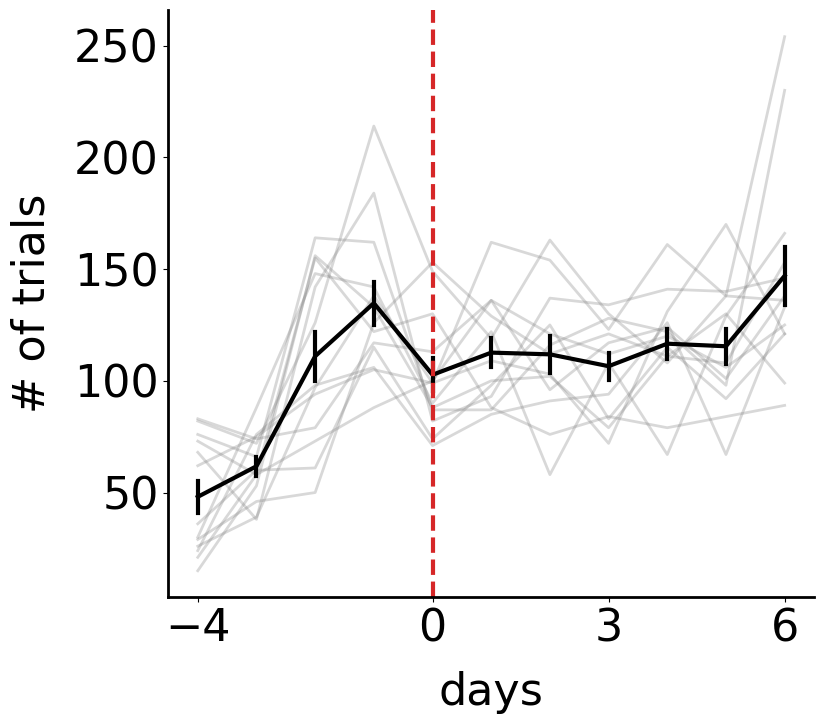

In [19]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trials for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trials'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trials'], 
             color='grey', alpha=0.3, linewidth=2)

# Main line plot (group average)
sns.lineplot(ax=ax1, data=line, x='date_index', y='trials', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_#_new.pdf',dpi = 300)
plt.show()

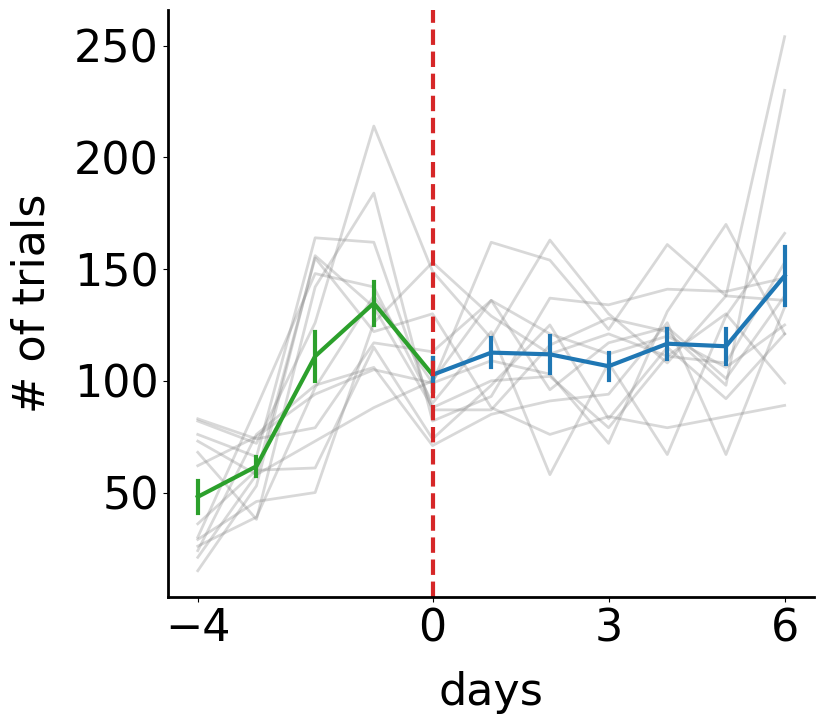

In [17]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trials for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trials'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trials'], 
             color='grey', alpha=0.3, linewidth=2)

# Split data into two segments for different colors
line_pre = line[line['date_index'] <=0]
line_post = line[line['date_index'] >= 0]

# Plot pre-day 0 segment in tab:green
if not line_pre.empty:
    sns.lineplot(ax=ax1, data=line_pre, x='date_index', y='trials', 
                 errorbar='se', err_style='bars', color='tab:green', 
                 linewidth=3, err_kws={'linewidth': 3})

# Plot post-day 0 segment in tab:blue  
if not line_post.empty:
    sns.lineplot(ax=ax1, data=line_post, x='date_index', y='trials', 
                 errorbar='se', err_style='bars', color='tab:blue', 
                 linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_#_new.pdf',dpi = 300)
plt.show()

Population Statistics (mean of animal means):
Day -4.0: Mean = 48.08 ± 7.20 SEM, n = 13.0
Day -3.0: Mean = 61.77 ± 4.22 SEM, n = 13.0
Day -2.0: Mean = 111.00 ± 10.94 SEM, n = 13.0
Day -1.0: Mean = 134.77 ± 9.59 SEM, n = 13.0
Day 0.0: Mean = 102.69 ± 7.36 SEM, n = 13.0
Day 1.0: Mean = 112.62 ± 6.57 SEM, n = 13.0
Day 2.0: Mean = 111.85 ± 8.14 SEM, n = 13.0
Day 3.0: Mean = 106.54 ± 5.97 SEM, n = 13.0
Day 4.0: Mean = 116.62 ± 6.68 SEM, n = 13.0
Day 5.0: Mean = 115.46 ± 7.82 SEM, n = 13.0
Day 6.0: Mean = 147.00 ± 13.07 SEM, n = 13.0


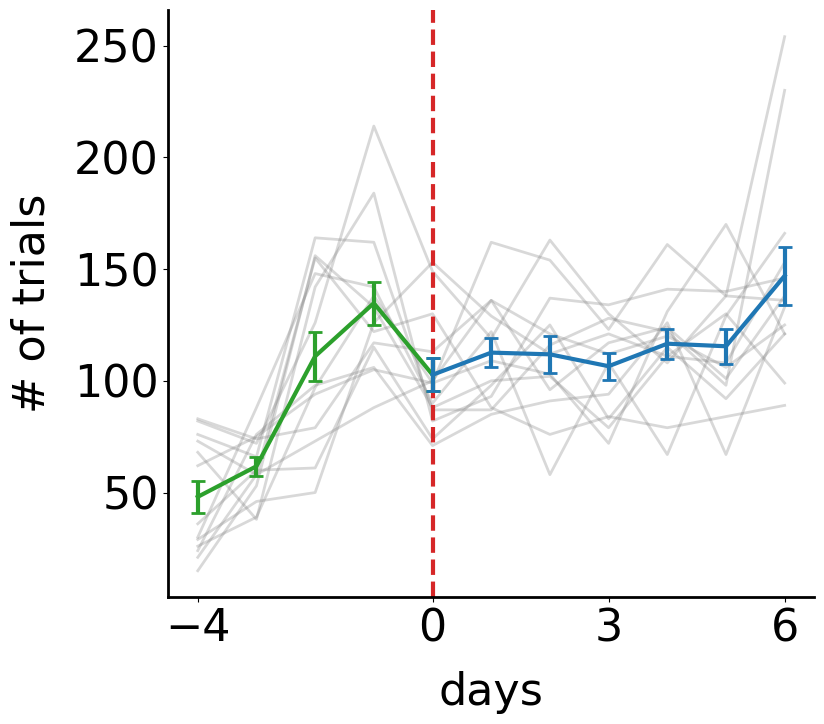

In [20]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Store all animal means for each day
all_animal_means = []

# Plot individual animal lines with low alpha in grey and collect means
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trials for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trials'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trials'], 
             color='grey', alpha=0.3, linewidth=2)
    
    # Store animal means for calculating population mean
    all_animal_means.append(animal_means)

# Create a DataFrame for population statistics
population_stats = []

# Calculate population mean as mean of animal means for each day
all_days = sorted(line['date_index'].unique())
for day in all_days:
    day_means = []
    for animal_df in all_animal_means:
        day_data = animal_df[animal_df['date_index'] == day]
        if not day_data.empty:
            day_means.append(day_data['trials'].values[0])
    
    if day_means:  # Only process days where we have data
        population_mean = np.mean(day_means)
        population_sem = np.std(day_means, ddof=1) / np.sqrt(len(day_means)) if len(day_means) > 1 else 0
        population_stats.append({
            'date_index': day,
            'mean': population_mean,
            'sem': population_sem,
            'n_animals': len(day_means)
        })

# Convert to DataFrame
population_df = pd.DataFrame(population_stats)

# Split population data into two segments for different colors
population_pre = population_df[population_df['date_index'] <= 0]
population_post = population_df[population_df['date_index'] >= 0]

# Plot pre-day 0 segment in tab:green using population means
if not population_pre.empty:
    # Plot the mean line
    ax1.plot(population_pre['date_index'], population_pre['mean'], 
             color='tab:green', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_pre['date_index'], population_pre['mean'],
                 yerr=population_pre['sem'], color='tab:green',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Plot post-day 0 segment in tab:blue using population means  
if not population_post.empty:
    # Plot the mean line
    ax1.plot(population_post['date_index'], population_post['mean'], 
             color='tab:blue', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_post['date_index'], population_post['mean'],
                 yerr=population_post['sem'], color='tab:blue',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Optional: Print population statistics
print("Population Statistics (mean of animal means):")
for _, row in population_df.iterrows():
    print(f"Day {row['date_index']}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, n = {row['n_animals']}")

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_#_new.pdf', dpi=300)
plt.show()

In [21]:
light_trial_permin

,animal,date,date_index,trialpermin,task,session_min,trials,trial_time
0,J701LT,030624,0.0,9.920298,oa,13.104444,130,5.250000
1,J701NN,030624,0.0,12.901412,oa,11.859167,153,4.100000
2,J701RN,030624,0.0,8.695864,oa,11.384722,99,5.616667
3,J701RT,030624,0.0,12.540078,oa,7.017500,88,4.266667
4,J701LT,030724,1.0,11.715976,oa,7.511111,88,4.400000
...,...,...,...,...,...,...,...,...
15,G8CK1TT,051523,-2.0,9.664594,oa,8.174167,79,4.350000
16,G8CK1LN,051623,-1.0,14.393968,oa,7.294722,105,2.966667
17,G8CK1LT,051623,-1.0,10.989886,oa,10.464167,115,3.483333
18,G8CK1RT,051623,-1.0,10.432721,oa,8.435000,88,3.216667


In [16]:
animal_means

,date_index,trials
0,-4.0,83.0
1,-3.0,74.0
2,-2.0,79.0
3,-1.0,117.0
4,0.0,113.0
5,1.0,136.0
6,2.0,121.0
7,3.0,112.0
8,4.0,120.0
9,5.0,106.0


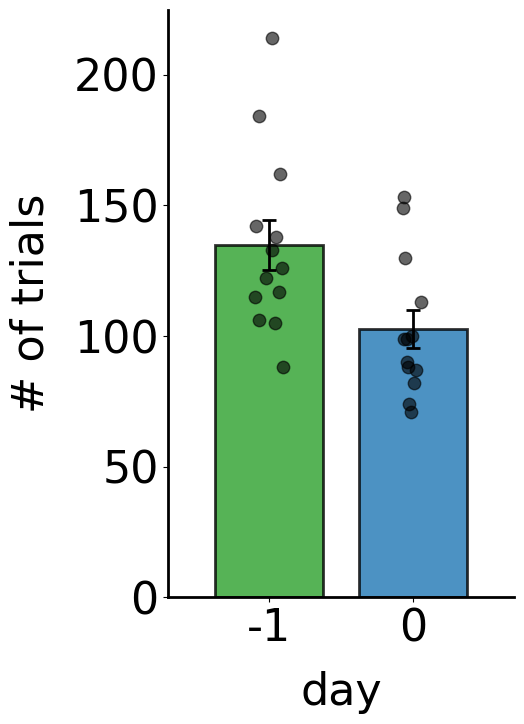

Summary Statistics:
Day -1: Mean = 134.77 ± 9.59 SEM, SD = 34.59, n = 13
Day 0: Mean = 102.69 ± 7.36 SEM, SD = 26.52, n = 13


In [26]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure with consistent font settings
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rc('axes', edgecolor='black')

fig, ax = plt.subplots(1, 1, figsize=(6, 8))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Small jitter

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean trials for this animal on this day
            animal_mean = animal_day_data['trials'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trials'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = 0.75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)


# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trials_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

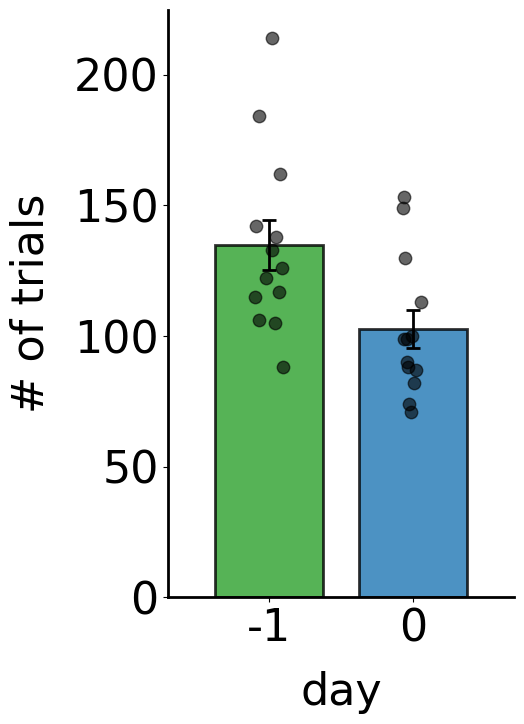

Summary Statistics:
Day -1: Mean = 134.77 ± 9.59 SEM, SD = 34.59, n = 13
Day 0: Mean = 102.69 ± 7.36 SEM, SD = 26.52, n = 13

PAIRED T-TEST RESULTS
Total animals: 13
Animals with complete data on both days: 13

Paired t-test (two-tailed):
t(12) = 3.071, p = 0.0097
Mean difference (Day 0 - Day -1): -32.077 ± 10.446 SEM
95% CI for mean difference: [-52.551, -11.603]
Significance: **

Individual animal data:
  Animal G8CK1LN: Day -1 = 105.00, Day 0 = 99.00, Difference = -6.00
  Animal G8CK1LT: Day -1 = 115.00, Day 0 = 74.00, Difference = -41.00
  Animal G8CK1RT: Day -1 = 88.00, Day 0 = 100.00, Difference = 12.00
  Animal G8CK1TT: Day -1 = 117.00, Day 0 = 113.00, Difference = -4.00
  Animal G8CKLN: Day -1 = 184.00, Day 0 = 82.00, Difference = -102.00
  Animal G8CKLT: Day -1 = 106.00, Day 0 = 71.00, Difference = -35.00
  Animal G8CKRN: Day -1 = 142.00, Day 0 = 90.00, Difference = -52.00
  Animal G8CKRT: Day -1 = 162.00, Day 0 = 87.00, Difference = -75.00
  Animal G8CKTT: Day -1 = 214.00, Da

In [7]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure with consistent font settings
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rc('axes', edgecolor='black')

fig, ax = plt.subplots(1, 1, figsize=(6, 8))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Small jitter

# Prepare data for paired t-test
day_minus1_data = []
day_0_data = []
paired_data = []  # Store pairs for t-test

# Plot individual scatter points for each animal and collect data for t-test
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean trials for this animal on this day
            animal_mean = animal_day_data['trials'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)
            
            # Collect data for t-test
            if day == -1:
                day_minus1_data.append(animal_mean)
            else:
                day_0_data.append(animal_mean)
            
            # Store for pairing
            paired_data.append({'animal': animal, 'day': day, 'mean_trials': animal_mean})

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trials'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = 0.75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trials_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

# Perform paired t-test
print("\n" + "="*50)
print("PAIRED T-TEST RESULTS")
print("="*50)

# Convert to DataFrame for easier pairing
import pandas as pd
paired_df = pd.DataFrame(paired_data)

# Create a pivot table to align data by animal
pivot_df = paired_df.pivot(index='animal', columns='day', values='mean_trials')
pivot_df = pivot_df.reset_index()

# Check if we have complete pairs (animals with data on both days)
complete_pairs = pivot_df.dropna()

print(f"Total animals: {len(unique_animals)}")
print(f"Animals with complete data on both days: {len(complete_pairs)}")

if len(complete_pairs) >= 2:
    # Perform paired t-test
    from scipy import stats
    
    # Extract paired data
    day_minus1_paired = complete_pairs[-1].values
    day_0_paired = complete_pairs[0].values
    
    # Perform the paired t-test
    t_stat, p_value = stats.ttest_rel(day_minus1_paired, day_0_paired)
    
    # Calculate descriptive statistics for the differences
    differences = day_0_paired - day_minus1_paired
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)  # Sample standard deviation
    sem_diff = std_diff / np.sqrt(len(differences))
    
    print(f"\nPaired t-test (two-tailed):")
    print(f"t({len(differences)-1}) = {t_stat:.3f}, p = {p_value:.4f}")
    print(f"Mean difference (Day 0 - Day -1): {mean_diff:.3f} ± {sem_diff:.3f} SEM")
    print(f"95% CI for mean difference: [{mean_diff - 1.96*sem_diff:.3f}, {mean_diff + 1.96*sem_diff:.3f}]")
    
    # Check for significance
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "ns"
    
    print(f"Significance: {significance}")
    
    # Print individual animal data
    print(f"\nIndividual animal data:")
    for idx, row in complete_pairs.iterrows():
        print(f"  Animal {row['animal']}: Day -1 = {row[-1]:.2f}, Day 0 = {row[0]:.2f}, Difference = {row[0] - row[-1]:.2f}")
        
else:
    print("\nCannot perform paired t-test: Need at least 2 animals with data on both days")
    print(f"Animals with complete data: {list(complete_pairs['animal'])}")

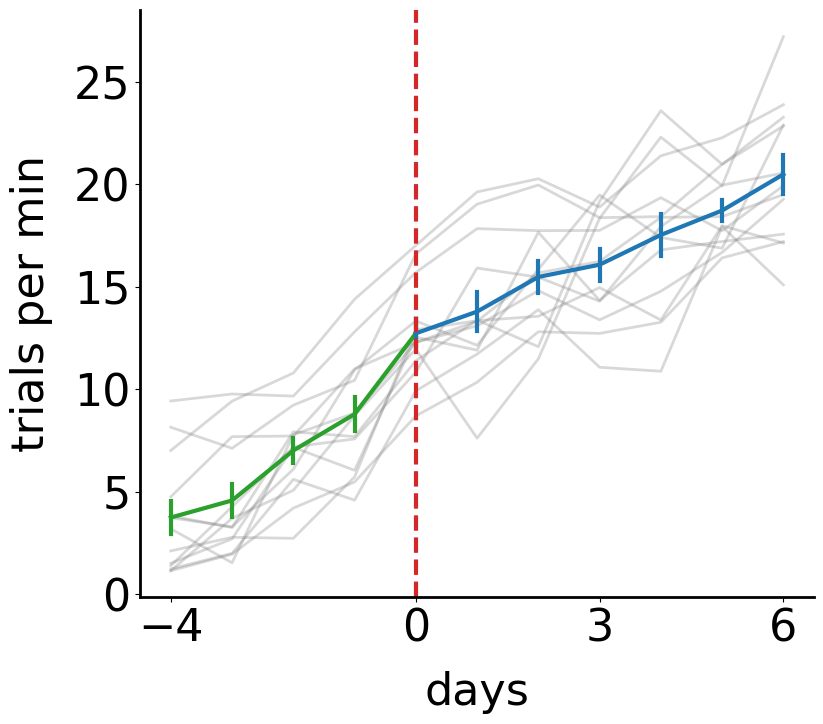

In [24]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trialpermin for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trialpermin'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trialpermin'], 
             color='grey', alpha=0.3, linewidth=2)

# Split data into two segments for different colors
line_pre = line[line['date_index'] <= 0]
line_post = line[line['date_index'] >= 0]

# Plot pre-day 0 segment in tab:green
if not line_pre.empty:
    sns.lineplot(ax=ax1, data=line_pre, x='date_index', y='trialpermin', 
                 errorbar='se', err_style='bars', color='tab:green', 
                 linewidth=3, err_kws={'linewidth': 3})

# Plot post-day 0 segment in tab:blue  
if not line_post.empty:
    sns.lineplot(ax=ax1, data=line_post, x='date_index', y='trialpermin', 
                 errorbar='se', err_style='bars', color='tab:blue', 
                 linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_new.pdf',dpi = 300)
plt.show()

Population Statistics (mean of animal means):
Day | Mean ± SEM | n animals
----------------------------------------
Day -4.0: Mean = 3.74 ± 0.79 SEM, n = 13.0
Day -3.0: Mean = 4.57 ± 0.80 SEM, n = 13.0
Day -2.0: Mean = 7.01 ± 0.63 SEM, n = 13.0
Day -1.0: Mean = 8.78 ± 0.83 SEM, n = 13.0
Day 0.0: Mean = 12.73 ± 0.69 SEM, n = 13.0
Day 1.0: Mean = 13.79 ± 0.96 SEM, n = 13.0
Day 2.0: Mean = 15.48 ± 0.78 SEM, n = 13.0
Day 3.0: Mean = 16.08 ± 0.77 SEM, n = 13.0
Day 4.0: Mean = 17.53 ± 1.04 SEM, n = 13.0
Day 5.0: Mean = 18.73 ± 0.53 SEM, n = 13.0
Day 6.0: Mean = 20.49 ± 0.94 SEM, n = 13.0


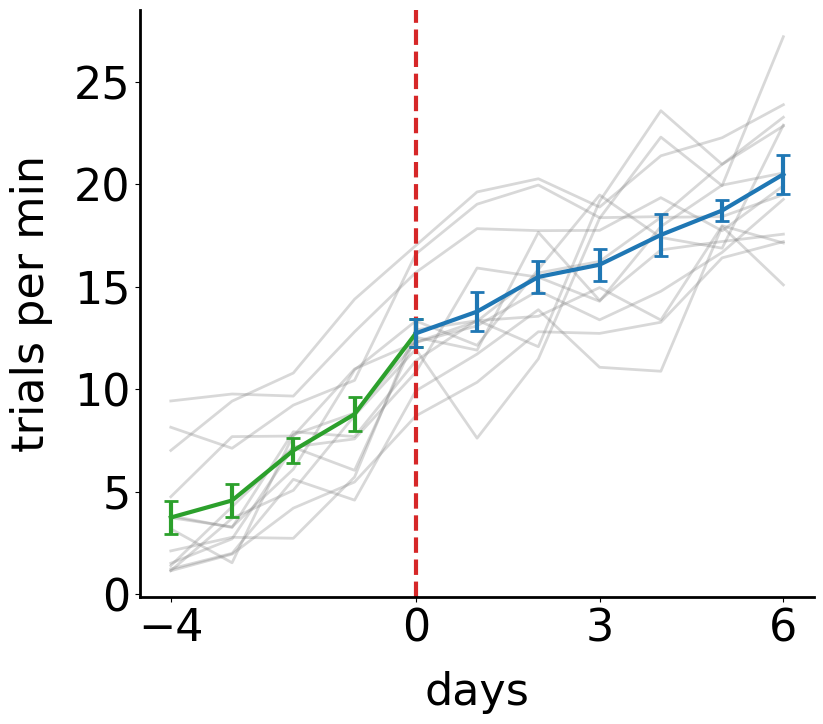

In [27]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Store all animal means for each day
all_animal_means = []

# Plot individual animal lines with low alpha in grey and collect means
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trialpermin for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trialpermin'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trialpermin'], 
             color='grey', alpha=0.3, linewidth=2)
    
    # Store animal means for calculating population mean
    all_animal_means.append(animal_means)

# Create a DataFrame for population statistics
population_stats = []

# Calculate population mean as mean of animal means for each day
all_days = sorted(line['date_index'].unique())
for day in all_days:
    day_means = []
    for animal_df in all_animal_means:
        day_data = animal_df[animal_df['date_index'] == day]
        if not day_data.empty:
            day_means.append(day_data['trialpermin'].values[0])
    
    if day_means:  # Only process days where we have data
        population_mean = np.mean(day_means)
        population_sem = np.std(day_means, ddof=1) / np.sqrt(len(day_means)) if len(day_means) > 1 else 0
        population_stats.append({
            'date_index': day,
            'mean': population_mean,
            'sem': population_sem,
            'n_animals': len(day_means)
        })

# Convert to DataFrame
population_df = pd.DataFrame(population_stats)

# Split population data into two segments for different colors
population_pre = population_df[population_df['date_index'] <= 0]
population_post = population_df[population_df['date_index'] >= 0]

# Plot pre-day 0 segment in tab:green using population means
if not population_pre.empty:
    # Plot the mean line
    ax1.plot(population_pre['date_index'], population_pre['mean'], 
             color='tab:green', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_pre['date_index'], population_pre['mean'],
                 yerr=population_pre['sem'], color='tab:green',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Plot post-day 0 segment in tab:blue using population means  
if not population_post.empty:
    # Plot the mean line
    ax1.plot(population_post['date_index'], population_post['mean'], 
             color='tab:blue', linewidth=3, zorder=5)
    
    # Add error bars (SEM)
    ax1.errorbar(population_post['date_index'], population_post['mean'],
                 yerr=population_post['sem'], color='tab:blue',
                 capsize=5, capthick=2, linewidth=3, fmt='none', zorder=5)

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Optional: Print population statistics
print("Population Statistics (mean of animal means):")
print("Day | Mean ± SEM | n animals")
print("-" * 40)
for _, row in population_df.iterrows():
    print(f"Day {row['date_index']}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, n = {row['n_animals']}")

#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_new.pdf', dpi=300)
plt.show()

In [23]:
population_df

,date_index,mean,sem,n_animals
0,-4.0,3.735111,0.787798,13
1,-3.0,4.568927,0.802834,13
2,-2.0,7.008148,0.626144,13
3,-1.0,8.783589,0.832429,13
4,0.0,12.728398,0.685058,13
5,1.0,13.790404,0.961827,13
6,2.0,15.482562,0.778741,13
7,3.0,16.081000,0.773860,13
8,4.0,17.534221,1.035892,13
9,5.0,18.725078,0.526374,13


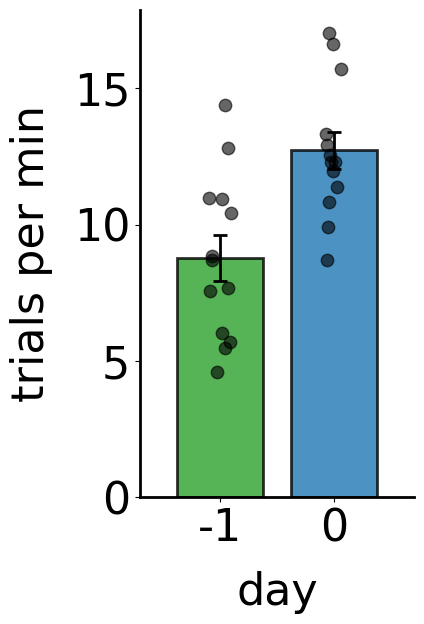

Summary Statistics:
Day -1: Mean = 8.78 ± 0.83 SEM, SD = 3.00, n = 13
Day 0: Mean = 12.73 ± 0.69 SEM, SD = 2.47, n = 13


In [25]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure
fig, ax = plt.subplots(1, 1, figsize=(5, 7))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5 (closer than before)
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Smaller jitter since bars are closer

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean for this animal on this day
            animal_mean = animal_day_data['trialpermin'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trialpermin'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = .75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

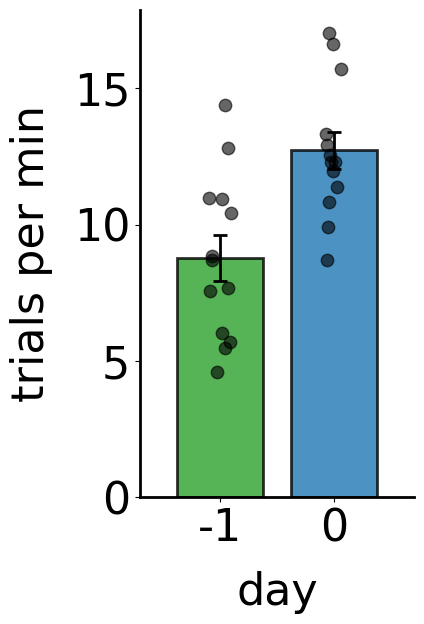

Summary Statistics:
Day -1: Mean = 8.78 ± 0.83 SEM, SD = 3.00, n = 13
Day 0: Mean = 12.73 ± 0.69 SEM, SD = 2.47, n = 13

PAIRED T-TEST RESULTS
Total animals: 13
Animals with complete data on both days: 13

Paired t-test (two-tailed):
t(12) = -7.994, p = 0.0000
Mean difference (Day 0 - Day -1): 3.945 ± 0.493 SEM
95% CI for mean difference: [2.978, 4.912]
Significance: ***

Individual animal data (trials per min):
  Animal G8CK1LN: Day -1 = 14.39, Day 0 = 17.02, Difference = 2.62
  Animal G8CK1LT: Day -1 = 10.99, Day 0 = 12.28, Difference = 1.30
  Animal G8CK1RT: Day -1 = 10.43, Day 0 = 16.60, Difference = 6.17
  Animal G8CK1TT: Day -1 = 12.80, Day 0 = 15.70, Difference = 2.90
  Animal G8CKLN: Day -1 = 8.84, Day 0 = 12.29, Difference = 3.46
  Animal G8CKLT: Day -1 = 8.71, Day 0 = 11.96, Difference = 3.24
  Animal G8CKRN: Day -1 = 7.57, Day 0 = 10.83, Difference = 3.26
  Animal G8CKRT: Day -1 = 7.69, Day 0 = 11.39, Difference = 3.70
  Animal G8CKTT: Day -1 = 10.94, Day 0 = 13.33, Differen

In [28]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure
fig, ax = plt.subplots(1, 1, figsize=(5, 7))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5 (closer than before)
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Smaller jitter since bars are closer

# Prepare data for paired t-test
day_minus1_data = []
day_0_data = []
paired_data = []  # Store pairs for t-test

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean for this animal on this day
            animal_mean = animal_day_data['trialpermin'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)
            
            # Collect data for t-test
            if day == -1:
                day_minus1_data.append(animal_mean)
            else:
                day_0_data.append(animal_mean)
            
            # Store for pairing
            paired_data.append({'animal': animal, 'day': day, 'mean_trialpermin': animal_mean})

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trialpermin'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = .75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

# Perform paired t-test
print("\n" + "="*50)
print("PAIRED T-TEST RESULTS")
print("="*50)

# Convert to DataFrame for easier pairing
import pandas as pd
paired_df = pd.DataFrame(paired_data)

# Create a pivot table to align data by animal
pivot_df = paired_df.pivot(index='animal', columns='day', values='mean_trialpermin')
pivot_df = pivot_df.reset_index()

# Check if we have complete pairs (animals with data on both days)
complete_pairs = pivot_df.dropna()

print(f"Total animals: {len(unique_animals)}")
print(f"Animals with complete data on both days: {len(complete_pairs)}")

if len(complete_pairs) >= 2:
    # Perform paired t-test
    from scipy import stats
    
    # Extract paired data
    day_minus1_paired = complete_pairs[-1].values
    day_0_paired = complete_pairs[0].values
    
    # Perform the paired t-test
    t_stat, p_value = stats.ttest_rel(day_minus1_paired, day_0_paired)
    
    # Calculate descriptive statistics for the differences
    differences = day_0_paired - day_minus1_paired
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)  # Sample standard deviation
    sem_diff = std_diff / np.sqrt(len(differences))
    
    print(f"\nPaired t-test (two-tailed):")
    print(f"t({len(differences)-1}) = {t_stat:.3f}, p = {p_value:.4f}")
    print(f"Mean difference (Day 0 - Day -1): {mean_diff:.3f} ± {sem_diff:.3f} SEM")
    print(f"95% CI for mean difference: [{mean_diff - 1.96*sem_diff:.3f}, {mean_diff + 1.96*sem_diff:.3f}]")
    
    # Check for significance
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "ns"
    
    print(f"Significance: {significance}")
    
    # Print individual animal data
    print(f"\nIndividual animal data (trials per min):")
    for idx, row in complete_pairs.iterrows():
        print(f"  Animal {row['animal']}: Day -1 = {row[-1]:.2f}, Day 0 = {row[0]:.2f}, Difference = {row[0] - row[-1]:.2f}")
    
    # Add significance stars to the plot if desired
    if p_value < 0.05:
        # Determine y position for significance line
        max_value = max(group_stats['mean'] + group_stats['sem'])
        y_pos = max_value * 1.1
        
        # Add significance line
        ax.plot([x_positions[0], x_positions[1]], [y_pos, y_pos], 'k-', linewidth=1.5)
        ax.text(np.mean(x_positions), y_pos * 1.02, significance, 
                ha='center', va='bottom', fontsize=28, fontweight='normal')
        
else:
    print("\nCannot perform paired t-test: Need at least 2 animals with data on both days")
    print(f"Animals with complete data: {list(complete_pairs['animal'])}")

print("\nNote: Paired t-test compares each animal's performance on Day -1 vs Day 0.")
print("This accounts for within-animal variability across days.")

In [59]:
light_dark

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,intial_distance,goal_distance_from_target_port,goal_angle_to_target_port,goal_lateral_error_to_target_port
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[0.4748630033916924, 13.206937651525928, 29.11...",17.107891,17.150953,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.5067424782757053, -3.975730695107509, -3.9...",left,23.0,"[22.0959312118867, 21.663251903654018, 21.2305...","[7.429573008006076, 3.8913678278574193, 6.6502...","[8.090737985945012, 8.097815708845173, 8.10489..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[5.1771296691027295, 55.096723742024594, 117.9...",16.703003,16.664893,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2.681299671880082, 4.408661208135752, 4.82935...",left,12.0,"[32.40458268960001, 31.682537511489265, 30.960...","[7.88523149777408, 6.681033882623484, 16.72080...","[5.699668885836058, 6.02997036219443, 6.360271..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,[49.773470466177024],21.682364,21.810839,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.5522916970620639, -0.8708074362329055, -0....",right,24.0,"[22.360668702782093, 21.628938184728185, 20.92...","[8.945629711439155, 6.775464098045578, 5.25602...","[7.575429066207144, 7.619104329372066, 7.57230..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[43.861660432756864, 64.82904966104601]",14.243221,14.215612,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.3559020814814273, -0.5258943041331365, -0....",right,11.0,"[33.23714013772765, 32.30934654354773, 31.3815...","[152.06101593094374, 111.6066552513647, 44.515...","[4.57016145059243, 5.210001667301693, 5.849841..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,[nan],30.510427,31.092952,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.2344531897695687, -2.0689609014932064, -2....",left,24.0,"[22.435908738967214, 21.42253700182775, 20.623...","[17.686200424649765, 21.192715249003555, 18.82...","[8.902605950208045, 8.912086263773013, 8.87631..."
...,...,...,...,...,...,...,...,..